In [ ]:
import numpy as np
import cvxpy as cp
import matplotlib.pyplot as plt
import ipywidgets as widgets
from IPython.display import display
from scipy.linalg import solve_discrete_are
from scipy.optimize import minimize
import matplotlib.patches as patches


import warnings

# Save the original solve method
_original_solve = cp.Problem.solve

# Determine the default solver preference
_preferred_solver = None
_solver_message = ""

if cp.MOSEK in cp.installed_solvers():
    _preferred_solver = cp.MOSEK
    _solver_message = "MOSEK"
elif cp.SCS in cp.installed_solvers():
    _preferred_solver = cp.SCS
    _solver_message = "SCS (MOSEK not available)"
else:
    # If neither MOSEK nor SCS are installed, let CVXPY pick its internal default
    _preferred_solver = None
    _solver_message = "default CVXPY solver (MOSEK and SCS not available)"


def _global_solve(self, *args, **kwargs):
    # If a solver isn't explicitly passed, use the preferred one
    if 'solver' not in kwargs and _preferred_solver is not None:
        kwargs['solver'] = _preferred_solver
    return _original_solve(self, *args, **kwargs)

# Override CVXPY's solve method globally
cp.Problem.solve = _global_solve

print(f"CVXPY is now globally configured to use {_solver_message} by default.")

CVXPY is now globally configured to use SCS (MOSEK not available) by default.


# Simulator

## Functions
Need to only execute the cell and pass to the next one.

In [ ]:
# ==========================================
# Burer-Monteiro Rank-1 Optimization
# ==========================================
def solve_burer_monteiro(Z_sdp, M_obj, H_X, H_VA, H_VB, K, N, n):
    """
    Solves the Burer-Monteiro Rank-1 optimization problem to enforce rank 1 on Z.
    This is achieved by substituting Z = y*y^T and solving a non-convex QCQP.
    Guaranteed to yield an LTI perturbation.

    Args:
        Z_sdp (np.ndarray): The initial SDP solution for Z, used to find a good starting point for y.
        M_obj (np.ndarray): The objective matrix for the optimization problem.
        H_X (np.ndarray): Matrix for constructing X from y.
        H_VA (np.ndarray): Matrix for constructing VA from y.
        H_VB (np.ndarray): Matrix for constructing VB from y.
        K (np.ndarray): The LQR gain matrix.
        N (int): The prediction horizon.
        n (int): The state dimension.

    Returns:
        tuple: A tuple containing:
            - float: The optimal objective value of the Burer-Monteiro problem.
            - np.ndarray: The rank-1 matrix Z_rank1 = y_opt * y_opt.T.
    """
    n_tot = Z_sdp.shape[0]
    M_obj = (M_obj + M_obj.T) / 2.0

    eigs, evecs = np.linalg.eigh(Z_sdp)
    best_obj_val = -np.inf
    y0 = None

    for i in range(len(eigs)):
        if eigs[i] > 1e-8:
            y_candidate = evecs[:, i] * np.sqrt(eigs[i])
            candidate_obj_val = y_candidate.T @ M_obj @ y_candidate
            if candidate_obj_val > best_obj_val:
                best_obj_val = candidate_obj_val
                y0 = y_candidate.copy()

    if y0 is None:
        y0 = np.zeros(n_tot)

    def obj(y): return -y.T @ M_obj @ y
    def obj_jac(y): return -2.0 * M_obj @ y

    def cons_init(y): return 1.0 - np.dot(y[0:n], y[0:n])
    def cons_init_jac(y):
        jac = np.zeros_like(y)
        jac[0:n] = -2.0 * y[0:n]
        return jac

    def get_matrices(y):
        X  = (H_X @ y).reshape(N, n).T
        VA = (H_VA @ y).reshape(N, n).T
        VB = (H_VB @ y).reshape(N, n).T
        KX = K @ X
        return X.T @ X, VA.T @ VA, VB.T @ VB, KX.T @ KX

    def cons_lmi_A(y):
        Gx, Gva, _, _ = get_matrices(y)
        return np.linalg.eigvalsh(Gx - Gva + 1e-7 * np.eye(N))

    def cons_lmi_B(y):
        _, _, Gvb, Gkx = get_matrices(y)
        return np.linalg.eigvalsh(Gkx - Gvb + 1e-7 * np.eye(N))

    constraints = [
        {'type': 'ineq', 'fun': cons_init, 'jac': cons_init_jac},
        {'type': 'ineq', 'fun': cons_lmi_A},
        {'type': 'ineq', 'fun': cons_lmi_B}
    ]

    res = minimize(obj, y0, method='SLSQP', jac=obj_jac, constraints=constraints,
                   options={'maxiter': 500, 'ftol': 1e-8, 'disp': False})

    y_opt = res.x
    Z_rank1 = np.outer(y_opt, y_opt)
    return -res.fun, Z_rank1


def random_delta(rows, cols):
    """
    Generates a random matrix with singular values scaled such that the largest
    singular value is 1.0, and others are uniformly distributed between 0 and 1.

    Args:
        rows (int): Number of rows for the matrix.
        cols (int): Number of columns for the matrix.

    Returns:
        np.ndarray: A random matrix with controlled singular values.
    """
    M = np.random.randn(rows, cols)
    u, s, vh = np.linalg.svd(M, full_matrices=False)
    s_rand = np.random.uniform(0, 1, size=s.shape)
    if len(s_rand) > 0:
        s_rand[0] = 1.0  # Force maximal L2 norm
    return u @ np.diag(s_rand) @ vh



def build_system_matrices(A11, A12, A21, A22, B1, B2, Q11, Q22, R11, S11, S22):
    """
    Constructs the system matrices A, B, Q, R, and S from individual scalar components.

    Args:
        A11 (float): (0,0) element of the A matrix.
        A12 (float): (0,1) element of the A matrix.
        A21 (float): (1,0) element of the A matrix.
        A22 (float): (1,1) element of the A matrix.
        B1 (float): (0,0) element of the B matrix.
        B2 (float): (1,0) element of the B matrix.
        Q11 (float): (0,0) element of the Q matrix.
        Q22 (float): (1,1) element of the Q matrix.
        R11 (float): (0,0) element of the R matrix.
        S11 (float): (0,0) element of the S matrix.
        S22 (float): (1,1) element of the S matrix.

    Returns:
        tuple: A tuple containing the matrices (A, B, Q, R, S_user).
    """
    A = np.array([[A11, A12], [A21, A22]], dtype=float)
    B = np.array([[B1], [B2]], dtype=float)
    Q = np.array([[Q11, 0.0], [0.0, Q22]], dtype=float)
    R = np.array([[R11]], dtype=float)
    S_user = np.array([[S11, 0.0], [0.0, S22]], dtype=float)
    return A, B, Q, R, S_user

def solve_nominal_lqr(A, B, Q, R):
    """
    Solves the Discrete-time Algebraic Riccati Equation (DARE) and computes
    the Linear Quadratic Regulator (LQR) gain K and the closed-loop system matrix Phi.

    Args:
        A (np.ndarray): System matrix A.
        B (np.ndarray): Input matrix B.
        Q (np.ndarray): State cost matrix Q.
        R (np.ndarray): Input cost matrix R.

    Returns:
        tuple: A tuple containing:
            - np.ndarray: The solution to the DARE, P.
            - np.ndarray: The LQR gain matrix, K.
            - np.ndarray: The closed-loop system matrix, Phi = A - B @ K.
            - np.ndarray: The augmented state cost matrix, Q_K = Q + K.T @ R @ K.

    Raises:
        ValueError: If the system is not stabilizable.
    """
    try:
        P = solve_discrete_are(A, B, Q, R)
    except Exception:
        raise ValueError("System not stabilizable (Check A and B)")
    K = np.linalg.inv(R + B.T @ P @ B) @ (B.T @ P @ A)
    Phi = A - B @ K
    Q_K = Q + K.T @ R @ K
    return P, K, Phi, Q_K

def build_pep_matrices(Phi, eps_A, eps_B, N, n=2):
    """
    Builds the matrices required for the Primal Extremal Perturbation (PEP) SDP formulation.
    These matrices relate the state and perturbation terms over the prediction horizon.

    Args:
        Phi (np.ndarray): The nominal closed-loop system matrix.
        eps_A (float): The bound for the A matrix perturbation.
        eps_B (float): The bound for the B matrix perturbation.
        N (int): The prediction horizon.
        n (int, optional): The state dimension. Defaults to 2.

    Returns:
        tuple: A tuple containing H_X, H_N, H_VA, H_VB matrices.
    """
    O_mat = np.vstack([np.linalg.matrix_power(Phi, i) for i in range(N)])
    T_mat = np.zeros((n*N, n*N))
    for i in range(N):
        for j in range(i):
            T_mat[i*n:(i+1)*n, j*n:(j+1)*n] = np.linalg.matrix_power(Phi, i - j - 1)

    H_X = np.hstack([O_mat, eps_A * T_mat, -eps_B * T_mat])
    H_N = np.hstack([
        np.linalg.matrix_power(Phi, N),
        np.hstack([eps_A * np.linalg.matrix_power(Phi, N - 1 - i) for i in range(N)]),
        np.hstack([-eps_B * np.linalg.matrix_power(Phi, N - 1 - i) for i in range(N)])
    ])
    H_VA = np.hstack([np.zeros((n*N, n)), np.eye(n*N), np.zeros((n*N, n*N))])
    H_VB = np.hstack([np.zeros((n*N, n)), np.zeros((n*N, n*N)), np.eye(n*N)])
    return H_X, H_N, H_VA, H_VB

def solve_primal_pep_sdp(K, Q_K, S_active, H_X, H_N, H_VA, H_VB, N, apply_bm, n=2):
    """
    Solves the Primal PEP Semidefinite Program (SDP) to find an upper bound
    on the worst-case cost.

    Args:
        K (np.ndarray): The LQR gain matrix.
        Q_K (np.ndarray): The augmented state cost matrix.
        S_active (np.ndarray): The terminal cost matrix.
        H_X (np.ndarray): Matrix from build_pep_matrices.
        H_N (np.ndarray): Matrix from build_pep_matrices.
        H_VA (np.ndarray): Matrix from build_pep_matrices.
        H_VB (np.ndarray): Matrix from build_pep_matrices.
        N (int): The prediction horizon.
        apply_bm (bool): Whether to apply Burer-Monteiro rank-1 optimization.
        n (int, optional): The state dimension. Defaults to 2.

    Returns:
        tuple: A tuple containing:
            - float: The SDP upper bound cost.
            - float: The cost after Burer-Monteiro optimization (or SDP cost if not applied).
            - np.ndarray: The Z matrix after Burer-Monteiro optimization (or SDP Z if not applied).
            - int: The numerical rank of the SDP solution Z.

    Raises:
        ValueError: If the primal SDP solver encounters an error.
    """
    n_tot = n + 2 * n * N
    Q_K_blk = np.kron(np.eye(N), Q_K)

    Z = cp.Variable((n_tot, n_tot), symmetric=True)
    Z_X = H_X @ Z @ H_X.T
    Z_VA, Z_VB = H_VA @ Z @ H_VA.T, H_VB @ Z @ H_VB.T
    G_X, G_VA, G_VB, G_KX = [cp.Variable((N, N), symmetric=True) for _ in range(4)]

    cons = [Z >> 0, cp.trace(Z[0:n, 0:n]) <= 1]
    for i in range(N):
        for j in range(i, N):
            cons.append(G_X[i,j] == cp.trace(Z_X[i*n:(i+1)*n, j*n:(j+1)*n]))
            cons.append(G_VA[i,j] == cp.trace(Z_VA[i*n:(i+1)*n, j*n:(j+1)*n]))
            cons.append(G_VB[i,j] == cp.trace(Z_VB[i*n:(i+1)*n, j*n:(j+1)*n]))
            cons.append(G_KX[i,j] == cp.trace(K.T @ K @ Z_X[i*n:(i+1)*n, j*n:(j+1)*n]))
    cons += [G_X - G_VA >> 0, G_KX - G_VB >> 0]

    M_obj = H_X.T @ Q_K_blk @ H_X + H_N.T @ S_active @ H_N
    prob_primal = cp.Problem(cp.Maximize(cp.trace(M_obj @ Z)), cons)

    try:
        prob_primal.solve()
    except cp.error.SolverError:
        raise ValueError("Primal SDP Solver Error")

    Z_val_sdp = Z.value
    sdp_cost = prob_primal.value

    eigs = np.linalg.eigvalsh(Z_val_sdp)
    rank_Z_sdp = np.sum(eigs > 1e-4 * max(np.max(eigs), 1e-12))

    if apply_bm:
        cost_bm, Z_val_bm = solve_burer_monteiro(Z_val_sdp, M_obj, H_X, H_VA, H_VB, K, N, n)
        return sdp_cost, cost_bm, Z_val_bm, rank_Z_sdp
    else:
        # Fallback if BM is off
        return sdp_cost, sdp_cost, Z_val_sdp, rank_Z_sdp

def get_monte_carlo_lower_bound(Phi, K, Q_K, S, eps_A, eps_B, N, n=2, m=1, num_sims=1000):
    """
    Estimates a lower bound on the worst-case cost using Monte Carlo simulations.
    It randomly samples perturbations and initial conditions to find a high-cost scenario.

    Args:
        Phi (np.ndarray): The nominal closed-loop system matrix.
        K (np.ndarray): The LQR gain matrix.
        Q_K (np.ndarray): The augmented state cost matrix.
        S (np.ndarray): The terminal cost matrix.
        eps_A (float): The bound for the A matrix perturbation.
        eps_B (float): The bound for the B matrix perturbation.
        N (int): The prediction horizon.
        n (int, optional): The state dimension. Defaults to 2.
        m (int, optional): The input dimension. Defaults to 1.
        num_sims (int, optional): Number of Monte Carlo simulations. Defaults to 1000.

    Returns:
        tuple: A tuple containing:
            - float: The maximum cost found during Monte Carlo simulations.
            - np.ndarray: The Delta_A perturbation that led to the max cost.
            - np.ndarray: The Delta_B perturbation that led to the max cost.
            - np.ndarray: The initial state x0 that led to the max cost.
    """
    max_cost = -1.0
    best_DA = np.zeros((n, n))
    best_DB = np.zeros((n, m))
    best_x0 = np.zeros(n)
    for _ in range(num_sims):
        Delta_A = eps_A * random_delta(n, n)
        Delta_B = eps_B * random_delta(n, m)
        Phi_D = Phi + Delta_A - Delta_B @ K
        P_curr = S
        for _ in range(N):
            P_curr = Q_K + Phi_D.T @ P_curr @ Phi_D
        w, v = np.linalg.eigh(P_curr)
        cost = w[-1]
        if cost > max_cost:
            max_cost = cost
            best_DA, best_DB = Delta_A, Delta_B
            best_x0 = v[:, -1]
    return max_cost, best_DA, best_DB, best_x0

def run_nlp_heuristic(x0_guess, DA_guess, DB_guess, Phi, K, Q_K, S, eps_A, eps_B, N, n=2, m=1):
    """
    Runs a Non-Linear Programming (NLP) heuristic to find a local worst-case
    LTI perturbation and initial condition that maximizes the finite-horizon cost.

    Args:
        x0_guess (np.ndarray): Initial guess for the worst-case initial state.
        DA_guess (np.ndarray): Initial guess for the Delta_A perturbation.
        DB_guess (np.ndarray): Initial guess for the Delta_B perturbation.
        Phi (np.ndarray): The nominal closed-loop system matrix.
        K (np.ndarray): The LQR gain matrix.
        Q_K (np.ndarray): The augmented state cost matrix.
        S (np.ndarray): The terminal cost matrix.
        eps_A (float): The bound for the A matrix perturbation.
        eps_B (float): The bound for the B matrix perturbation.
        N (int): The prediction horizon.
        n (int, optional): The state dimension. Defaults to 2.
        m (int, optional): The input dimension. Defaults to 1.

    Returns:
        dict: A dictionary containing:
            - 'cost' (float): The worst-case cost found by the NLP.
            - 'Phi_wc' (np.ndarray): The worst-case closed-loop system matrix.
            - 'traj_s' (list): List of state vectors in the worst-case trajectory.
            - 'traj_n' (list): List of norms of state vectors in the worst-case trajectory.
            - 'x0' (np.ndarray): The worst-case initial state.
    """
    def pack(x0, DA, DB): return np.concatenate([x0, DA.flatten(), DB.flatten()])
    def unpack(theta):
        return theta[:n], theta[n : n + n*n].reshape((n, n)), theta[n + n*n :].reshape((n, m))
    def cost_fn(theta):
        x0, DA, DB = unpack(theta)
        Phi_wc = Phi + DA - DB @ K
        x = x0
        J = 0.0
        for _ in range(N):
            J += (x.T @ Q_K @ x)
            x = Phi_wc @ x
        J +=  (x.T @ S @ x)
        return -J

    cons = [{'type': 'eq', 'fun': lambda theta: 1.0 - np.sum(unpack(theta)[0]**2)}]
    if eps_A > 0: cons.append({'type': 'ineq', 'fun': lambda theta: eps_A - np.linalg.norm(unpack(theta)[1], ord=2)})
    if eps_B > 0: cons.append({'type': 'ineq', 'fun': lambda theta: eps_B - np.linalg.norm(unpack(theta)[2], ord=2)})

    bnds = [(-1.0, 1.0)] * n + [(-eps_A, eps_A)] * (n*n) + [(-eps_B, eps_B)] * (n*m)
    theta0 = pack(x0_guess, DA_guess, DB_guess)

    res = minimize(cost_fn, theta0, method='SLSQP', bounds=bnds, constraints=cons,
                   options={'maxiter': 500, 'ftol': 1e-8, 'disp': False})

    x0_f, DA_f, DB_f = unpack(res.x)
    if np.linalg.norm(x0_f) > 1e-8: x0_f = x0_f / max(1.0, np.linalg.norm(x0_f))

    if eps_A > 0:
        u, s, vh = np.linalg.svd(DA_f, full_matrices=False)
        DA_f = u @ np.diag(np.minimum(s, eps_A)) @ vh
    if eps_B > 0:
        u, s, vh = np.linalg.svd(DB_f, full_matrices=False)
        DB_f = u @ np.diag(np.minimum(s, eps_B)) @ vh

    Phi_wc = Phi + DA_f - DB_f @ K
    x = x0_f
    true_valid_cost = 0.0
    traj_s, traj_n = [x0_f], [np.linalg.norm(x0_f)]
    for _ in range(N):
        true_valid_cost += (x.T @ Q_K @ x)
        x = Phi_wc @ x
        traj_s.append(x); traj_n.append(np.linalg.norm(x))
    true_valid_cost +=  (x.T @ S @ x)

    return {'cost': true_valid_cost, 'Phi_wc': Phi_wc, 'traj_s': traj_s, 'traj_n': traj_n, 'x0': x0_f}

def extract_worst_case_trajectories(Z_val, Phi, Q_K, S_active, eps_A, eps_B, N, n=2):
    """
    Extracts the worst-case trajectory from the solution of the PEP SDP (Z_val).
    This involves decomposing Z to find the worst-case initial state and effective perturbations.

    Args:
        Z_val (np.ndarray): The solution matrix Z from the PEP SDP.
        Phi (np.ndarray): The nominal closed-loop system matrix.
        Q_K (np.ndarray): The augmented state cost matrix.
        S_active (np.ndarray): The terminal cost matrix.
        eps_A (float): The bound for the A matrix perturbation.
        eps_B (float): The bound for the B matrix perturbation.
        N (int): The prediction horizon.
        n (int, optional): The state dimension. Defaults to 2.

    Returns:
        dict: A dictionary containing:
            - 'traj_ext_s' (list): List of state vectors in the extracted worst-case trajectory.
            - 'traj_ext_n' (list): List of norms of state vectors in the extracted trajectory.
            - 'cost_ext' (float): The cost of the extracted trajectory.
            - 'Delta_eff' (np.ndarray): The effective LTI perturbation extracted.
            - 'Phi_wc' (np.ndarray): The reconstructed worst-case closed-loop system matrix.
    """
    eigs, evecs = np.linalg.eigh(Z_val)
    y_ext = evecs[:, np.argmax(eigs)] * np.sqrt(max(np.max(eigs), 0.0))

    x0_ext = y_ext[0:n]
    vA_ext, vB_ext = y_ext[n : n + n*N], y_ext[n + n*N : n + 2*n*N]

    traj_s, traj_n, cost, x_c = [x0_ext], [np.linalg.norm(x0_ext)], 0, x0_ext
    for k in range(N):
        cost += (x_c.T @ Q_K @ x_c)
        x_n = Phi @ x_c + eps_A * vA_ext[k*n:(k+1)*n] - eps_B * vB_ext[k*n:(k+1)*n]
        traj_s.append(x_n); traj_n.append(np.linalg.norm(x_n))
        x_c = x_n

    cost += (x_c.T @ S_active @ x_c)
    X_in = np.column_stack(traj_s[:-1])
    V_eff = np.column_stack([eps_A * vA_ext[k*n:(k+1)*n] - eps_B * vB_ext[k*n:(k+1)*n] for k in range(N)])

    try:
        Delta_eff = V_eff @ np.linalg.pinv(X_in)
    except:
        Delta_eff = np.zeros((n,n))

    return {
        'traj_ext_s': traj_s, 'traj_ext_n': traj_n, 'cost_ext': cost,
        'Delta_eff': Delta_eff, 'Phi_wc': Phi + Delta_eff
    }

def run_monte_carlo_simulations(x0, Phi, K, Q_K, S_active, eps_A, eps_B, N, num_sims=120, n=2, m=1):
    """
    Runs multiple Monte Carlo simulations of the closed-loop system with random
    LTI perturbations within the specified bounds. It also computes the nominal
    trajectory for comparison.

    Args:
        x0 (np.ndarray): The initial state for simulations.
        Phi (np.ndarray): The nominal closed-loop system matrix.
        K (np.ndarray): The LQR gain matrix.
        Q_K (np.ndarray): The augmented state cost matrix.
        S_active (np.ndarray): The terminal cost matrix.
        eps_A (float): The bound for the A matrix perturbation.
        eps_B (float): The bound for the B matrix perturbation.
        N (int): The prediction horizon.
        num_sims (int, optional): Number of Monte Carlo simulations. Defaults to 120.
        n (int, optional): The state dimension. Defaults to 2.
        m (int, optional): The input dimension. Defaults to 1.

    Returns:
        tuple: A tuple containing:
            - list: Nominal trajectory state vectors.
            - list: Nominal trajectory state norms.
            - float: Total nominal cost.
            - list: List of lists, where each inner list contains state vectors
                    for a single Monte Carlo simulation.
            - list: List of lists, where each inner list contains state norms
                    for a single Monte Carlo simulation.
    """
    traj_nom_s, traj_nom_n, cost_nom = [x0], [np.linalg.norm(x0)], 0
    x_curr = x0
    for i in range(N):
        cost_nom +=  (x_curr.T @ Q_K @ x_curr)
        x_curr = Phi @ x_curr
        traj_nom_s.append(x_curr)
        traj_nom_n.append(np.linalg.norm(x_curr))

    cost_nom_total = cost_nom + (x_curr.T @ S_active @ x_curr)

    sim_s, sim_n, costs = [], [], []
    for _ in range(num_sims):
        Phi_delta = Phi + eps_A * random_delta(n, n) - eps_B * random_delta(n, m) @ K
        t_s, t_n, c = [x0], [np.linalg.norm(x0)], 0
        x_curr = x0
        for i in range(N):
            c +=  (x_curr.T @ Q_K @ x_curr)
            x_curr = Phi_delta @ x_curr
            t_s.append(x_curr)
            t_n.append(np.linalg.norm(x_curr))

        costs.append(c +  (x_curr.T @ S_active @ x_curr))
        sim_s.append(t_s); sim_n.append(t_n)

    return traj_nom_s, traj_nom_n, cost_nom_total, sim_s, sim_n

# ==========================================
# Pseudospectral Heuristic
# ==========================================
def run_pseudospectral_heuristic(Phi, K, Q_K, S_active, eps_A, eps_B, N, n=2, m=1, num_samples=6000):
    """
    Finds the LTI perturbation that maximizes the spectral radius (asymptotic worst-case),
    and computes its exact finite-horizon cost to demonstrate the difference between
    transient and asymptotic bounds.

    Args:
        Phi (np.ndarray): The nominal closed-loop system matrix.
        K (np.ndarray): The LQR gain matrix.
        Q_K (np.ndarray): The augmented state cost matrix.
        S_active (np.ndarray): The terminal cost matrix.
        eps_A (float): The bound for the A matrix perturbation.
        eps_B (float): The bound for the B matrix perturbation.
        N (int): The prediction horizon.
        n (int, optional): The state dimension. Defaults to 2.
        m (int, optional): The input dimension. Defaults to 1.
        num_samples (int, optional): Number of random perturbations to sample.
                                     Defaults to 6000.

    Returns:
        dict: A dictionary containing:
            - 'cost' (float): The finite-horizon cost for the pseudospectral worst-case.
            - 'Phi_wc' (np.ndarray): The worst-case closed-loop system matrix.
            - 'traj_s' (list): List of state vectors for the pseudospectral worst-case trajectory.
            - 'traj_n' (list): List of norms of state vectors for the pseudospectral worst-case trajectory.
            - 'x0' (np.ndarray): The worst-case initial state for this perturbation.
            - 'max_radius' (float): The maximum spectral radius found.
    """
    if eps_A > 0:
        M_A = np.random.randn(num_samples, n, n)
        U_A, S_A, Vh_A = np.linalg.svd(M_A)
        Sr_A = np.random.uniform(0, 1, size=S_A.shape)
        Sr_A[:, 0] = 1.0 # Force max singular value to 1 to sit on the boundary
        DA_batch = eps_A * ((U_A * Sr_A[:, np.newaxis, :]) @ Vh_A)
    else:
        DA_batch = np.zeros((num_samples, n, n))

    if eps_B > 0:
        M_B = np.random.randn(num_samples, n, m)
        U_B, S_B, Vh_B = np.linalg.svd(M_B, full_matrices=False)
        Sr_B = np.random.uniform(0, 1, size=S_B.shape)
        Sr_B[:, 0] = 1.0
        DB_batch = eps_B * ((U_B * Sr_B[:, np.newaxis, :]) @ Vh_B)
    else:
        DB_batch = np.zeros((num_samples, n, m))

    K_batch = np.broadcast_to(K, (num_samples, m, n))
    Phi_batch = Phi + DA_batch - DB_batch @ K_batch

    eigs_batch = np.linalg.eigvals(Phi_batch)
    radii = np.max(np.abs(eigs_batch), axis=1)
    best_idx = np.argmax(radii)

    Phi_wc_ps = Phi_batch[best_idx]

    P_curr = S_active
    for _ in range(N):
        P_curr = Q_K + Phi_wc_ps.T @ P_curr @ Phi_wc_ps
    w, v = np.linalg.eigh(P_curr)
    x0_ps = v[:, -1]

    true_valid_cost = 0.0
    x = x0_ps
    traj_s, traj_n = [x0_ps], [np.linalg.norm(x0_ps)]
    for _ in range(N):
        true_valid_cost += (x.T @ Q_K @ x)
        x = Phi_wc_ps @ x
        traj_s.append(x); traj_n.append(np.linalg.norm(x))
    true_valid_cost += (x.T @ S_active @ x)

    return {
        'cost': true_valid_cost, 'Phi_wc': Phi_wc_ps,
        'traj_s': traj_s, 'traj_n': traj_n, 'x0': x0_ps,
        'max_radius': radii[best_idx]
    }


def solve_pep_2d(A11, A12, A21, A22, B1, B2, Q11, Q22, R11, S11, S22, eps_A, eps_B, N, apply_bm, num_sims):
    """
    Main function to solve the PEP problem for a 2D system and compute various
    worst-case costs and trajectories.

    Args:
        A11 (float): (0,0) element of the A matrix.
        A12 (float): (0,1) element of the A matrix.
        A21 (float): (1,0) element of the A matrix.
        A22 (float): (1,1) element of the A matrix.
        B1 (float): (0,0) element of the B matrix.
        B2 (float): (1,0) element of the B matrix.
        Q11 (float): (0,0) element of the Q matrix.
        Q22 (float): (1,1) element of the Q matrix.
        R11 (float): (0,0) element of the R matrix.
        S11 (float): (0,0) element of the S matrix.
        S22 (float): (1,1) element of the S matrix.
        eps_A (float): The bound for the A matrix perturbation.
        eps_B (float): The bound for the B matrix perturbation.
        N (int): The prediction horizon.
        apply_bm (bool): Whether to apply Burer-Monteiro rank-1 optimization.
        num_sims (int): Number of Monte Carlo simulations for the NLP heuristic initialization.

    Returns:
        tuple: A tuple containing:
            - dict: A dictionary of results including costs, trajectories, and system matrices.
            - str: A status message ('Success' or error message).
    """
    A, B, Q, R, S_user = build_system_matrices(A11, A12, A21, A22, B1, B2, Q11, Q22, R11, S11, S22)
    n_dim, m_dim = B.shape

    try:
        P, K, Phi, Q_K = solve_nominal_lqr(A, B, Q, R)
    except ValueError as e:
        return None, str(e)

    S_active, mode_str = S_user, "User S"
    H_X, H_N, H_VA, H_VB = build_pep_matrices(Phi, eps_A, eps_B, N)

    try:
        sdp_cost, cost_bm, Z_val_bm, rank_Z_sdp = solve_primal_pep_sdp(K, Q_K, S_active, H_X, H_N, H_VA, H_VB, N, apply_bm)
    except ValueError as e:
        return None, str(e)

    ext_bm = extract_worst_case_trajectories(Z_val_bm, Phi, Q_K, S_active, eps_A, eps_B, N)

    # 1. NLP Heuristic (Maximizing Finite Horizon Cost)
    mc_max, DA_mc, DB_mc, x0_mc = get_monte_carlo_lower_bound(Phi, K, Q_K, S_active, eps_A=eps_A, eps_B=eps_B, N=N, n=n_dim, m=m_dim, num_sims=num_sims)
    nlp_res = run_nlp_heuristic(x0_mc, DA_mc, DB_mc, Phi, K, Q_K, S_active, eps_A, eps_B, N, n_dim, m_dim)

    # 2. Pseudospectral Heuristic (Maximizing Asymptotic Spectral Radius)
    ps_res = run_pseudospectral_heuristic(Phi, K, Q_K, S_active, eps_A, eps_B, N, n_dim, m_dim, num_samples=6000)

    t_nom_s, t_nom_n, c_nom, sim_s, sim_n = run_monte_carlo_simulations(
        ext_bm['traj_ext_s'][0], Phi, K, Q_K, S_active, eps_A, eps_B, N
    )

    res = {
        'N': N, 'mode_str': mode_str, 'Phi': Phi, 'K': K,
        'sdp_cost': sdp_cost, 'cost_bm': cost_bm,
        'traj_bm_s': ext_bm['traj_ext_s'], 'traj_bm_n': ext_bm['traj_ext_n'],
        'rank_Z_sdp': rank_Z_sdp, 'is_tight': (rank_Z_sdp == 1),
        'traj_nom_s': t_nom_s, 'traj_nom_n': t_nom_n,
        'sim_s': sim_s, 'sim_n': sim_n, 'Phi_wc_bm': ext_bm['Phi_wc'],
        'nlp_cost': nlp_res['cost'], 'nlp_traj_s': nlp_res['traj_s'],
        'nlp_traj_n': nlp_res['traj_n'], 'nlp_Phi_wc': nlp_res['Phi_wc'],
        # New PS Data
        'ps_cost': ps_res['cost'], 'ps_traj_s': ps_res['traj_s'],
        'ps_traj_n': ps_res['traj_n'], 'ps_Phi_wc': ps_res['Phi_wc']
    }
    return res, "Success"


# ==========================================
# Interactive Plotting Function
# ==========================================
def update_plot(A11, A12, A21, A22, B1, B2, Q11, Q22, R11, S11, S22, eps_A, eps_B, N, apply_bm, num_sims):
    """
    Updates the interactive plot based on the provided system parameters.
    This function is intended to be used with ipywidgets' interactive_output.

    Args:
        A11 (float): (0,0) element of the A matrix.
        A12 (float): (0,1) element of the A matrix.
        A21 (float): (1,0) element of the A matrix.
        A22 (float): (1,1) element of the A matrix.
        B1 (float): (0,0) element of the B matrix.
        B2 (float): (1,0) element of the B matrix.
        Q11 (float): (0,0) element of the Q matrix.
        Q22 (float): (1,1) element of the Q matrix.
        R11 (float): (0,0) element of the R matrix.
        S11 (float): (0,0) element of the S matrix.
        S22 (float): (1,1) element of the S matrix.
        eps_A (float): The bound for the A matrix perturbation.
        eps_B (float): The bound for the B matrix perturbation.
        N (int): The prediction horizon.
        apply_bm (bool): Whether to apply Burer-Monteiro rank-1 optimization.
        num_sims (int): Number of Monte Carlo simulations for the NLP heuristic initialization.
    """
    res, msg = solve_pep_2d(A11, A12, A21, A22, B1, B2, Q11, Q22, R11, S11, S22, eps_A, eps_B, int(N), apply_bm, num_sims)

    fig, ax_dict = plt.subplot_mosaic([['ax1', 'ax4'], ['ax2', 'ax4'], ['ax3', 'ax4']], figsize=(15, 9))
    ax1, ax2, ax3, ax4 = ax_dict['ax1'], ax_dict['ax2'], ax_dict['ax3'], ax_dict['ax4']

    if res is None:
        fig.suptitle(msg, color='red', fontsize=18, fontweight='bold')
        for ax in [ax1, ax2, ax3, ax4]:
            ax.set_xticks([]); ax.set_yticks([])
        plt.show(); return

    # --- Subplot 1: Time Evolution ---
    for i, traj in enumerate(res['sim_n']):
        ax1.plot(range(res['N']+1), traj, color='#1f77b4', alpha=0.08)
    ax1.plot(range(res['N']+1), res['traj_nom_n'], color='#2ca02c', lw=3, label="Nominal Trajectory", zorder=5)
    ax1.plot(range(res['N']+1), res['traj_bm_n'], color='#d62728', lw=3, linestyle='--', label=f"BM Worst-Case (LTI)", zorder=6)
    ax1.plot(range(res['N']+1), res['nlp_traj_n'], color='darkorange', lw=2.5, linestyle='-.', label=f"NLP Exact (LTI)", zorder=7)
    ax1.plot(range(res['N']+1), res['ps_traj_n'], color='magenta', lw=2.5, linestyle=':', label=f"PS Heuristic (LTI)", zorder=8)

    ax1.set_title(r"Time Evolution (State Norm $\|x_k\|_2$)", fontsize=13)
    ax1.set_xlabel("Time Step $k$")
    ax1.set_ylabel(r"$\|x_k\|$")
    ax1.grid(True, linestyle=':', alpha=0.7)
    ax1.legend(loc='upper right')

    t_str = "Exact Bound" if res['is_tight'] else "LTV Conservatism"

    # Phase Plot Prep
    all_x = [s[0] for t in res['sim_s'] for s in t] + [s[0] for s in res['traj_nom_s']] + \
            [s[0] for s in res['traj_bm_s']] + [s[0] for s in res['nlp_traj_s']] + [s[0] for s in res['ps_traj_s']]
    all_y = [s[1] for t in res['sim_s'] for s in t] + [s[1] for s in res['traj_nom_s']] + \
            [s[1] for s in res['traj_bm_s']] + [s[1] for s in res['nlp_traj_s']] + [s[1] for s in res['ps_traj_s']]

    min_x, max_x, min_y, max_y = min(all_x), max(all_x), min(all_y), max(all_y)
    pad_x, pad_y = max(0.1*(max_x - min_x), 0.1), max(0.1*(max_y - min_y), 0.1)

    nx1, nx2 = [s[0] for s in res['traj_nom_s']], [s[1] for s in res['traj_nom_s']]
    ex1, ex2 = [s[0] for s in res['traj_bm_s']], [s[1] for s in res['traj_bm_s']]
    nx_nlp1, nx_nlp2 = [s[0] for s in res['nlp_traj_s']], [s[1] for s in res['nlp_traj_s']]
    nx_ps1, nx_ps2 = [s[0] for s in res['ps_traj_s']], [s[1] for s in res['ps_traj_s']]
    Y, X = np.mgrid[min_y - pad_y : max_y + pad_y : 20j, min_x - pad_x : max_x + pad_x : 20j]

    # --- Subplot 2: Nominal Flow ---
    ax2.set_title(r"Nominal Flow Field & Phase Portrait", fontsize=13)
    U_nom = (res['Phi'][0,0] - 1)*X + res['Phi'][0,1]*Y
    V_nom = res['Phi'][1,0]*X + (res['Phi'][1,1] - 1)*Y
    ax2.quiver(X, Y, U_nom, V_nom, color='#2ca02c', alpha=0.3)
    for traj in res['sim_s']:
        ax2.plot([s[0] for s in traj], [s[1] for s in traj], color='#1f77b4', alpha=0.08, lw=1)
    ax2.plot(nx1, nx2, color='#2ca02c', lw=3, marker='o', markersize=4, zorder=5, label="Nominal Traj")
    ax2.plot(ex1, ex2, color='#d62728', lw=3, linestyle='--', marker='x', markersize=6, zorder=6, label="BM Traj")
    ax2.plot(nx_nlp1, nx_nlp2, color='darkorange', lw=2, linestyle='-.', marker='d', markersize=5, zorder=7, label="NLP Traj")
    ax2.plot(nx_ps1, nx_ps2, color='magenta', lw=2, linestyle=':', marker='*', markersize=6, zorder=8, label="PS Traj")
    ax2.legend(loc='best')

    # --- Subplot 3: Dominant LTI Worst-Case Flow ---
    if res['nlp_cost'] > res['cost_bm']:
        best_Phi_wc, best_label = res['nlp_Phi_wc'], "NLP LTI"
    else:
        best_Phi_wc, best_label = res['Phi_wc_bm'], "BM LTI"

    ax3.set_title(f"Dominant Worst-Case Flow Field ({best_label})", fontsize=13)
    U_wc = (best_Phi_wc[0,0] - 1)*X + best_Phi_wc[0,1]*Y
    V_wc = best_Phi_wc[1,0]*X + (best_Phi_wc[1,1] - 1)*Y

    ax3.quiver(X, Y, U_wc, V_wc, color='indigo', alpha=0.20)
    ax3.plot(nx1, nx2, color='#2ca02c', lw=2, linestyle=':', marker='o', markersize=4, alpha=0.6, label="Nominal Traj")
    ax3.plot(ex1, ex2, color='#d62728', lw=3, linestyle='--', marker='x', markersize=6, zorder=6, label="BM Traj")
    ax3.plot(nx_nlp1, nx_nlp2, color='darkorange', lw=2, linestyle='-.', marker='d', markersize=5, zorder=7, label="NLP Traj")
    ax3.plot(nx_ps1, nx_ps2, color='magenta', lw=2, linestyle=':', marker='*', markersize=6, zorder=8, label="PS Traj")
    ax3.legend(loc='best')

    for ax in [ax2, ax3]:
        ax.set_xlim(min_x - pad_x, max_x + pad_x); ax.set_ylim(min_y - pad_y, max_y + pad_y)
        ax.set_xlabel("State $x_1$"); ax.set_ylabel("State $x_2$")
        ax.grid(True, linestyle=':', alpha=0.7)
        ax.axhline(0, color='black', lw=0.5); ax.axvline(0, color='black', lw=0.5)

    # --- Subplot 4: Spectral Targeting ---
    ax4.set_title("Structured Uncertainty & Spectral Targeting", fontsize=13)
    eigs_nom = np.linalg.eigvals(res['Phi'])
    eigs_wc_bm = np.linalg.eigvals(res['Phi_wc_bm'])
    eigs_nlp = np.linalg.eigvals(res['nlp_Phi_wc'])
    eigs_ps = np.linalg.eigvals(res['ps_Phi_wc'])

    theta_uc = np.linspace(0, 2*np.pi, 200)
    ax4.plot(np.cos(theta_uc), np.sin(theta_uc), 'k-', lw=1.5, alpha=0.4, label='Unit Circle')

    # Generate Cloud for plotting
    A, B, Q, R, _ = build_system_matrices(A11, A12, A21, A22, B1, B2, Q11, Q22, R11, S11, S22)
    _, K, _, _ = solve_nominal_lqr(A, B, Q, R)
    n, m = B.shape

    N_samples = 6000
    M_A = np.random.randn(N_samples, n, n)
    U_A, _, Vh_A = np.linalg.svd(M_A)
    S_rand_A = np.random.uniform(0, 1, size=(N_samples, n))
    Delta_A = (U_A * S_rand_A[:, np.newaxis, :]) @ Vh_A
    M_B = np.random.randn(N_samples, n, m)
    M_B_norms = np.linalg.norm(M_B, axis=1, keepdims=True)
    S_rand_B = np.random.uniform(0, 1, size=(N_samples, 1, 1))
    Delta_B = (M_B / M_B_norms) * S_rand_B

    K_batch = np.broadcast_to(K, (N_samples, m, n))
    Phi_batch = res['Phi'] + eps_A * Delta_A - eps_B * (Delta_B @ K_batch)
    eigs_batch = np.linalg.eigvals(Phi_batch).flatten()
    eigs_radii = np.abs(eigs_batch)

    ax4.scatter(eigs_batch.real, eigs_batch.imag, c='black',
                s=2, alpha=0.35, zorder=2, edgecolors='none', label='Structured Cloud')

    # Draw lines connecting nominal to the worst-case shifts
    for en, ew in zip(np.sort_complex(eigs_nom), np.sort_complex(eigs_wc_bm)):
        ax4.plot([en.real, ew.real], [en.imag, ew.imag], 'k:', lw=1.8, alpha=0.6, zorder=4)

    ax4.scatter(eigs_nom.real, eigs_nom.imag, s=110, c='#2ca02c', edgecolors='white', marker='o', zorder=5, label='Nominal Eigs')
    ax4.scatter(eigs_wc_bm.real, eigs_wc_bm.imag, s=150, c='#d62728', edgecolors='white', marker='X', zorder=6, label='BM (LTI) Eigs')
    ax4.scatter(eigs_nlp.real, eigs_nlp.imag, s=120, c='darkorange', edgecolors='white', marker='D', zorder=7, label='NLP (LTI) Eigs')
    ax4.scatter(eigs_ps.real, eigs_ps.imag, s=160, c='magenta', edgecolors='white', marker='*', zorder=8, label='PS (LTI) Eigs')

    ax4.set_xlim(-1.2, 1.2); ax4.set_ylim(-1.2, 1.2)
    ax4.set_aspect('equal')
    ax4.set_xlabel("Real Part"); ax4.set_ylabel("Imaginary Part")
    ax4.grid(True, linestyle=':', alpha=0.7)
    ax4.axhline(0, color='black', lw=0.5); ax4.axvline(0, color='black', lw=0.5)
    handles, labels = ax4.get_legend_handles_labels()
    ax4.legend(handles, labels, loc='best', fontsize=8, framealpha=0.9, edgecolor='black')

    lines = [
        (f"Verification Dashboard ({res['mode_str']}):", 'black'),
        (f"• Original SDP Rank:      {res['rank_Z_sdp']} ({t_str})", 'black'),
        (f"• SDP Upper Bound (LTV):  {res['sdp_cost']:.4f}", 'purple'),
        (f"• BM Lower Bound (LTI):   {res['cost_bm']:.4f}", '#d62728'),
        (f"• NLP Lower Bound (LTI):  {res['nlp_cost']:.4f}", 'darkorange'),
        (f"• PS Lower Bound (LTI):   {res['ps_cost']:.4f}", 'magenta'),
    ]
    for i, (txt, col) in enumerate(lines):
        ax4.text(0.025, 1.36 - i*0.05, txt, color=col, transform=ax4.transAxes,
                 fontsize=11, fontweight='bold', family='monospace', zorder=11)

    plt.tight_layout(pad=2.0)
    plt.show()


# ==========================================
# Create UI Dashboard Layout
# ==========================================
sl_layout, sl_style = widgets.Layout(width='95%'), {'description_width': '40%'}
def make_slider(desc, val, min_v, max_v, step_v=0.01):
    """
    Creates a FloatSlider widget with predefined layout and style.

    Args:
        desc (str): Description for the slider.
        val (float): Initial value of the slider.
        min_v (float): Minimum value of the slider.
        max_v (float): Maximum value of the slider.
        step_v (float, optional): Step size for the slider. Defaults to 0.01.

    Returns:
        ipywidgets.FloatSlider: The configured float slider widget.
    """
    return widgets.FloatSlider(value=val, min=min_v, max=max_v, step=step_v, description=desc, style=sl_style, layout=sl_layout)




## Simulator interface

In [ ]:
w_A11, w_A12 = make_slider('A11', 1.0, -2, 2), make_slider('A12', 1.0, -2, 2)
w_A21, w_A22 = make_slider('A21', 0.0, -2, 2), make_slider('A22', 1.0, -2, 2)
w_B1, w_B2 = make_slider('B1', 0.0, -2, 2), make_slider('B2', 1.0, -2, 2)

w_Q11, w_Q22 = make_slider('Q11', 1.0, 0.1, 10), make_slider('Q22', 1.0, 0.1, 10)
w_R11 = make_slider('R11', 1.0, 0.1, 10)
w_S11, w_S22 = make_slider('S11', 1.0, 0.0, 50), make_slider('S22', 1.0, 0.0, 50)

w_epsA, w_epsB = make_slider(r'ε_A', 0.08, 0, 0.5, 0.01), make_slider(r'ε_B', 0.02, 0, 0.5, 0.01)
w_N = widgets.IntSlider(value=5, min=1, max=25, description='Horizon N', style=sl_style, layout=sl_layout)

w_bm = widgets.Checkbox(value=True, description='Apply Burer-Monteiro QCQP', style=sl_style, layout=sl_layout)
w_num_sims_MC = widgets.IntSlider(value=1000, min=50, max=5000, description='Num MC trajectories', style=sl_style, layout=sl_layout)

ui = widgets.HBox([
    widgets.VBox([widgets.HTML("<b>Plant Dynamics</b>"), w_A11, w_A12, w_A21, w_A22, w_B1, w_B2], layout=widgets.Layout(width='25%')),
    widgets.VBox([widgets.HTML("<b>Cost Matrices</b>"), w_Q11, w_Q22, w_R11, w_S11, w_S22], layout=widgets.Layout(width='25%')),
    widgets.VBox([widgets.HTML("<b>PEP Configuration</b>"), w_epsA, w_epsB, w_N], layout=widgets.Layout(width='25%')),
    widgets.VBox([widgets.HTML("<b>Rank Constraints</b>"), w_bm, w_num_sims_MC], layout=widgets.Layout(width='25%'))
])

out = widgets.interactive_output(update_plot, {
    'A11': w_A11, 'A12': w_A12, 'A21': w_A21, 'A22': w_A22, 'B1': w_B1, 'B2': w_B2,
    'Q11': w_Q11, 'Q22': w_Q22, 'R11': w_R11, 'S11': w_S11, 'S22': w_S22,
    'eps_A': w_epsA, 'eps_B': w_epsB, 'N': w_N,
    'apply_bm': w_bm, 'num_sims' : w_num_sims_MC
})
display(ui, out)

Output()

# Functions to make Figure 1.

In [ ]:
import scipy.ndimage as ndimage
import matplotlib.patches as mpatches
import matplotlib as mpl
mpl.rcParams.update(mpl.rcParamsDefault)

# ==========================================
# Matplotlib Global Settings
# ==========================================
mpl.rcParams['font.family'] = 'serif'
mpl.rcParams['font.size'] = 8
mpl.rcParams['axes.titlesize'] = 9
mpl.rcParams['axes.labelsize'] = 7
mpl.rcParams['xtick.labelsize'] = 7
mpl.rcParams['ytick.labelsize'] = 7
mpl.rcParams['legend.fontsize'] = 7

mpl.rcParams['xtick.major.size'] = 3.5
mpl.rcParams['xtick.minor.size'] = 2.0
mpl.rcParams['xtick.major.width'] = 0.8
mpl.rcParams['xtick.minor.width'] = 0.6
mpl.rcParams['xtick.direction'] = 'out'
mpl.rcParams['xtick.top'] = False
mpl.rcParams['xtick.bottom'] = True
mpl.rcParams['ytick.direction'] = 'out'
mpl.rcParams['ytick.left'] = True
mpl.rcParams['ytick.right'] = False

mpl.rcParams['grid.linewidth'] = .8
mpl.rcParams['grid.color'] = 'lightgrey'
mpl.rcParams['grid.linestyle'] = '6,2'

mpl.rcParams['axes.linewidth'] = 0.5
mpl.rcParams['axes.labelpad'] = 4.0
mpl.rcParams['axes.spines.top'] = True
mpl.rcParams['axes.spines.right'] = True
mpl.rcParams['axes.spines.left'] = True
mpl.rcParams['axes.spines.bottom'] = True
mpl.rcParams['axes.axisbelow'] = True
mpl.rcParams['axes.xmargin'] = 0

# ==========================================
# 1. Plotting Configuration & Parameters
# ==========================================
FIG_SIZE_RECT = (2.3, 2.3)
FIG_SIZE_SQ   = (2.3, 2.3)
FIG_DPI       = 300

C_NOM      = '#5B9A64'
C_WC       = '#C1121F'
C_SIM      = '#006AA3'
C_FLOW_WC  = '#d62728'
C_CLOUD    = None

LW_NOM     = .75
LW_WC      = .75
LW_SIM     = 0.5

LS_NOM     = '-'
LS_WC      = 'dashed'
LS_NOM_ALT = '-'

M_NOM      = 'o'
M_WC       = 's'
M_WC_EIG   = '*'
MS_NOM     = 4
MS_WC      = 3
MS_NOM_EIG = 60
MS_WC_EIG  = 100

ALPHA_SIM      = 0.08
ALPHA_FLOW_NOM = 0.65
ALPHA_FLOW_WC  = 0.65

ADD_ARROWS  = True
ARROW_STYLE = '->'
ARROW_SIZE  = 10

def add_trajectory_arrows(ax, x_coords, y_coords, color, lw, ls, zorder):
    if not ADD_ARROWS: return
    for i in range(len(x_coords)-1):
        ax.annotate('', xy=(x_coords[i+1], y_coords[i+1]), xytext=(x_coords[i], y_coords[i]),
                    arrowprops=dict(arrowstyle=ARROW_STYLE, color=color, lw=lw,
                                    linestyle=ls, mutation_scale=ARROW_SIZE,
                                    shrinkA=0, shrinkB=0),
                    zorder=zorder)


def generate_2D_rotations(N):
    theta = np.random.uniform(0, 2*np.pi, N)
    C, S = np.cos(theta), np.sin(theta)
    R = np.zeros((N, 2, 2))
    R[:, 0, 0], R[:, 0, 1] = C, -S
    R[:, 1, 0], R[:, 1, 1] = S, C
    flips = np.random.choice([1, -1], size=(N, 1, 1))
    return R * flips

def generate_perturbation_cloud(Phi, K, eps_A, eps_B, N_samples=30000, n=2, m=1):
    M_A = np.random.randn(N_samples, n, n)
    U_A, _, Vh_A = np.linalg.svd(M_A)
    S_rand_A = np.random.uniform(0, 1, size=(N_samples, n))
    Delta_A_1 = (U_A * S_rand_A[:, np.newaxis, :]) @ Vh_A

    M_B = np.random.randn(N_samples, n, m)
    M_B_norms = np.linalg.norm(M_B, axis=1, keepdims=True)
    S_rand_B = np.random.uniform(0, 1, size=(N_samples, 1, 1))
    Delta_B_1 = (M_B / M_B_norms) * S_rand_B

    K_batch_1 = np.broadcast_to(K, (N_samples, m, n))
    Phi_batch_1 = Phi + eps_A * Delta_A_1 - eps_B * (Delta_B_1 @ K_batch_1)
    eigs_batch_1 = np.linalg.eigvals(Phi_batch_1).flatten()

    if n == 2:
        U_str = generate_2D_rotations(N_samples)
        V_str = generate_2D_rotations(N_samples)
        Sig_str = np.zeros((N_samples, n, n))
        Sig_str[:, 0, 0] = 1.0
        Sig_str[:, 1, 1] = np.random.uniform(-1, 1, N_samples)
        Delta_A_2 = U_str @ Sig_str @ np.transpose(V_str, (0, 2, 1))

        theta_b = np.random.uniform(0, 2*np.pi, N_samples)
        Delta_B_2 = np.zeros((N_samples, n, m))
        Delta_B_2[:, 0, 0] = np.cos(theta_b)
        Delta_B_2[:, 1, 0] = np.sin(theta_b)

        K_batch_2 = np.broadcast_to(K, (N_samples, m, n))
        Phi_batch_2 = Phi + eps_A * Delta_A_2 - eps_B * (Delta_B_2 @ K_batch_2)
        eigs_batch_2 = np.linalg.eigvals(Phi_batch_2).flatten()
        return np.concatenate((eigs_batch_1, eigs_batch_2))

    return eigs_batch_1

# ==========================================
# 3. Solver Orchestrator
# ==========================================
def solve_pep_2d(A11, A12, A21, A22, B1, B2, Q11, Q22, R11, S11, S22, eps_A, eps_B, N, apply_bm, num_sims):
    A, B, Q, R, S_user = build_system_matrices(A11, A12, A21, A22, B1, B2, Q11, Q22, R11, S11, S22)
    n_dim, m_dim = B.shape

    try:
        P, K, Phi, Q_K = solve_nominal_lqr(A, B, Q, R)
    except ValueError as e: return None, str(e)

    S_active, mode_str = S_user, "User S"
    H_X, H_N, H_VA, H_VB = build_pep_matrices(Phi, eps_A, eps_B, N)

    try:
        sdp_cost, cost_bm, Z_val_bm, rank_Z_sdp = solve_primal_pep_sdp(K, Q_K, S_active, H_X, H_N, H_VA, H_VB, N, apply_bm)
    except ValueError as e: return None, str(e)

    # BM Trajectories
    ext_bm = extract_worst_case_trajectories(Z_val_bm, Phi, Q_K, S_active, eps_A, eps_B, N)

    # NLP / MC Trajectories
    mc_max, DA_mc, DB_mc, x0_mc = get_monte_carlo_lower_bound(Phi, K, Q_K, S_active, eps_A, eps_B, N, n_dim, m_dim, num_sims)
    nlp_res = run_nlp_heuristic(x0_mc, DA_mc, DB_mc, Phi, K, Q_K, S_active, eps_A, eps_B, N, n_dim, m_dim)

    # Select best worst-case extracted trajectory (Maximum of BM and MC-NLP approaches)
    best_cost = max(cost_bm, nlp_res['cost'])

    if best_cost == nlp_res['cost']:
        traj_ext_s, traj_ext_n, Phi_wc, wc_method = nlp_res['traj_s'], nlp_res['traj_n'], nlp_res['Phi_wc'], "MC-NLP"
    else:
        traj_ext_s, traj_ext_n, Phi_wc, wc_method = ext_bm['traj_ext_s'], ext_bm['traj_ext_n'], ext_bm['Phi_wc'], "BM"

    # Perform nominal simulations
    t_nom_s, t_nom_n, c_nom, sim_s, sim_n = run_monte_carlo_simulations(
        traj_ext_s[0], Phi, K, Q_K, S_active, eps_A, eps_B, N, num_sims=num_sims
    )

    return {
        'N': N, 'mode_str': mode_str, 'wc_method': wc_method,
        'gamma_N': sdp_cost, 'cost_ext': best_cost,
        'traj_ext_s': traj_ext_s, 'traj_ext_n': traj_ext_n,
        'rank_Z': rank_Z_sdp, 'is_tight': (rank_Z_sdp == 1),
        'traj_nom_s': t_nom_s, 'traj_nom_n': t_nom_n, 'cost_nom': c_nom,
        'sim_s': sim_s, 'sim_n': sim_n,
        'Phi': Phi, 'Phi_wc': Phi_wc, 'K': K
    }, "Success"

# ==========================================
# 4. Generate Simulation and PDFs
# ==========================================


def plot_function(res, name):

    all_x = [s[0] for t in res['sim_s'] for s in t] + [s[0] for s in res['traj_nom_s']] + [s[0] for s in res['traj_ext_s']]
    all_y = [s[1] for t in res['sim_s'] for s in t] + [s[1] for s in res['traj_nom_s']] + [s[1] for s in res['traj_ext_s']]
    min_x, max_x, min_y, max_y = min(all_x), max(all_x), min(all_y), max(all_y)
    pad_x, pad_y = max(0.15*(max_x - min_x), 0.1), max(0.15*(max_y - min_y), 0.1)

    nx1, nx2 = [s[0] for s in res['traj_nom_s']], [s[1] for s in res['traj_nom_s']]
    ex1, ex2 = [s[0] for s in res['traj_ext_s']], [s[1] for s in res['traj_ext_s']]
    Y, X = np.mgrid[min_y - pad_y : max_y + pad_y : 20j, min_x - pad_x : max_x + pad_x : 20j]

    # ------------------------------------------
    # Plot 1: Time Evolution
    # ------------------------------------------
    fig1, ax1 = plt.subplots(figsize=FIG_SIZE_RECT, dpi=FIG_DPI)
    for i, traj in enumerate(res['sim_n']):
        ax1.plot(range(res['N']+1), traj, color=C_SIM, alpha=ALPHA_SIM)

    ax1.plot(range(res['N']+1), res['traj_nom_n'], color=C_NOM, lw=LW_NOM, ls=LS_NOM, label="Nominal Trajectory", zorder=5)
    ax1.plot(range(res['N']+1), res['traj_ext_n'], color=C_WC, lw=LW_WC, ls=LS_WC, label=f"Worst-Case ({res['wc_method']})", zorder=6)

    ax1.set_xlabel("Time Step $k$")
    ax1.set_ylabel(r"$\|x_k\|$")
    ax1.grid(True)
    ax1.legend(loc='upper right')

    t_str = "Exact Bound" if res['is_tight'] else "LTV Conservatism"
    sanity_text = (
        f"Verification Dashboard:\n"
        f"• SDP Upper Bound: {res['gamma_N']:.4f}\n"
        f"• {res['wc_method']} Lower Bound: {res['cost_ext']:.4f}\n"
        f"• Rank(Z): {res['rank_Z']} ({t_str})"
    )
    t_color = 'green' if res['is_tight'] else 'red'
    ax1.text(0.02, 0.02, sanity_text, transform=ax1.transAxes, fontsize=5,
             verticalalignment='bottom', bbox=dict(boxstyle='round', facecolor='white', alpha=0.9, edgecolor=t_color, lw=2))

    fig1.savefig(f"{name}_time_evolution.pdf", bbox_inches='tight', format="pdf")
    plt.show()
    plt.close(fig1)

    # ------------------------------------------
    # Plot 2: Nominal Flow
    # ------------------------------------------
    fig2, ax2 = plt.subplots(figsize=FIG_SIZE_RECT, dpi=FIG_DPI)
    U_nom = (res['Phi'][0,0] - 1)*X + res['Phi'][0,1]*Y
    V_nom = res['Phi'][1,0]*X + (res['Phi'][1,1] - 1)*Y
    ax2.quiver(X, Y, U_nom, V_nom, color=C_NOM, alpha=ALPHA_FLOW_NOM)

    for traj in res['sim_s']:
        ax2.plot([s[0] for s in traj], [s[1] for s in traj], color=C_SIM, alpha=ALPHA_SIM, lw=LW_SIM)

    add_trajectory_arrows(ax2, nx1, nx2, C_NOM, LW_NOM, LS_NOM, zorder=5)
    add_trajectory_arrows(ax2, ex1, ex2, C_WC, LW_WC, LS_WC, zorder=6)

    ax2.plot([], [], color=C_NOM, lw=LW_NOM, ls=LS_NOM, marker=M_NOM, markersize=MS_NOM, label="Nominal Traj")
    ax2.plot([], [], color=C_WC, lw=LW_WC, ls=LS_WC, marker=M_WC, markersize=MS_WC, label="Worst-Case Traj")
    ax2.legend(loc='best')
    ax2.set_xlim(min_x - pad_x, max_x + pad_x); ax2.set_ylim(min_y - pad_y, max_y + pad_y)
    ax2.set_xlabel("State $x_1$"); ax2.set_ylabel("State $x_2$")
    ax2.grid(True)
    ax2.axhline(0, color='black', lw=0.5); ax2.axvline(0, color='black', lw=0.5)

    fig2.savefig(f"{name}_nominal_flow.pdf", bbox_inches='tight', format="pdf")
    plt.show()

    plt.close(fig2)

    # ------------------------------------------
    # Plot 3: Worst-Case Flow
    # ------------------------------------------
    fig3, ax3 = plt.subplots(figsize=FIG_SIZE_RECT, dpi=FIG_DPI)
    ax3.set_xlim(min_x - pad_x, max_x + pad_x); ax3.set_ylim(min_y - pad_y, max_y + pad_y)
    ax3.set_xlabel("State $x_1$"); ax3.set_ylabel("State $x_2$")
    ax3.grid(True)
    ax3.axhline(0, color='black', lw=0.5); ax3.axvline(0, color='black', lw=0.5)

    ax3.quiver(X, Y, U_nom, V_nom, color=C_NOM, alpha=ALPHA_FLOW_NOM)
    U_wc = (res['Phi_wc'][0,0] - 1)*X + res['Phi_wc'][0,1]*Y
    V_wc = res['Phi_wc'][1,0]*X + (res['Phi_wc'][1,1] - 1)*Y
    ax3.quiver(X, Y, U_wc, V_wc, color=C_FLOW_WC, alpha=ALPHA_FLOW_WC)

    ax3.scatter(nx1, nx2, color=C_NOM, marker=M_NOM, s=MS_NOM, alpha=1, zorder=5)
    add_trajectory_arrows(ax3, nx1, nx2, C_NOM, LW_NOM, LS_NOM_ALT, zorder=5)

    ax3.scatter(ex1, ex2, color=C_WC, marker=M_WC, s=MS_WC, zorder=6)
    add_trajectory_arrows(ax3, ex1, ex2, C_WC, LW_WC, LS_WC, zorder=6)

    fig3.savefig(f"{name}_worst_case_flow.pdf", bbox_inches='tight', format="pdf")
    plt.show()
    plt.close(fig3)

    # ------------------------------------------
    # Plot 4: Dense Spectral Targeting + Contour
    # ------------------------------------------
    fig4, ax4 = plt.subplots(figsize=FIG_SIZE_SQ, dpi=FIG_DPI)

    eigs_nom = np.linalg.eigvals(res['Phi'])
    eigs_wc = np.linalg.eigvals(res['Phi_wc'])

    # Unit Circle
    theta_uc = np.linspace(0, 2*np.pi, 200)
    ax4.plot(np.cos(theta_uc), np.sin(theta_uc), '-', c='black', lw=1, label='Unit Circle')

    # Perturbation Cloud
    eigs_batch = generate_perturbation_cloud(
        Phi=res['Phi'], K=res['K'], eps_A=params['eps_A'], eps_B=params['eps_B'],
        N_samples=120000, n=2, m=1
    )
    ax4.axhline(0, color='black', lw=0.5); ax4.axvline(0, color='black', lw=0.5)

    cloud_color = "#ffaa0f"
    ax4.scatter(eigs_batch.real, eigs_batch.imag, c=cloud_color, cmap=C_CLOUD,
                s=2, alpha=0.1, zorder=2, edgecolors='none', rasterized=True)

    # Draw Connecting Lines (Nominal to Worst-Case)
    for en, ew in zip(np.sort_complex(eigs_nom), np.sort_complex(eigs_wc)):
        ax4.plot([en.real, ew.real], [en.imag, ew.imag], 'k:', lw=1.8, alpha=0.8, zorder=4)

    # Scatter Nominal and Worst-Case Eigs
    ax4.scatter(eigs_nom.real, eigs_nom.imag, s=MS_NOM_EIG, c=C_NOM, marker=M_NOM, zorder=5, label='Nominal')
    ax4.scatter(eigs_wc.real, eigs_wc.imag, s=MS_WC_EIG, c=C_WC, marker=M_WC_EIG, zorder=6, label='Worst-Case')

    ax4.set_xlim(-1.1, 1.1); ax4.set_ylim(-1.1, 1.1)
    ax4.set_aspect('equal')
    ax4.set_xlabel("Real Part")
    ax4.set_ylabel("Imaginary Part")
    ax4.grid(True)

    # Custom Legend Configuration
    handles, labels = ax4.get_legend_handles_labels()
    cloud_patch = mpatches.Patch(facecolor=cloud_color, alpha=0.8)
    handles.append(cloud_patch)
    labels.append(r'$\Lambda_\varepsilon(\Phi)$ Pert.')

    fig4.savefig(f"{name}_spectral_targeting.pdf", bbox_inches='tight', format="pdf")
    plt.show()
    plt.close(fig4)

    print("Success! Saved 4 files: \n"
          f"- '{name}_time_evolution.pdf'\n"
          f"- '{name}_nominal_flow.pdf'\n"
          f"- '{name}_worst_case_flow.pdf'\n"
          f"- '{name}_spectral_targeting.pdf'")

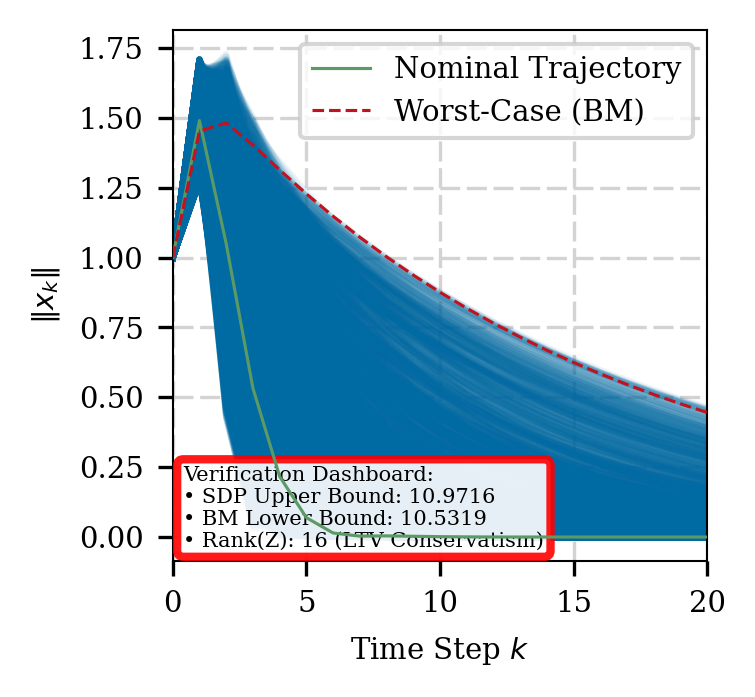

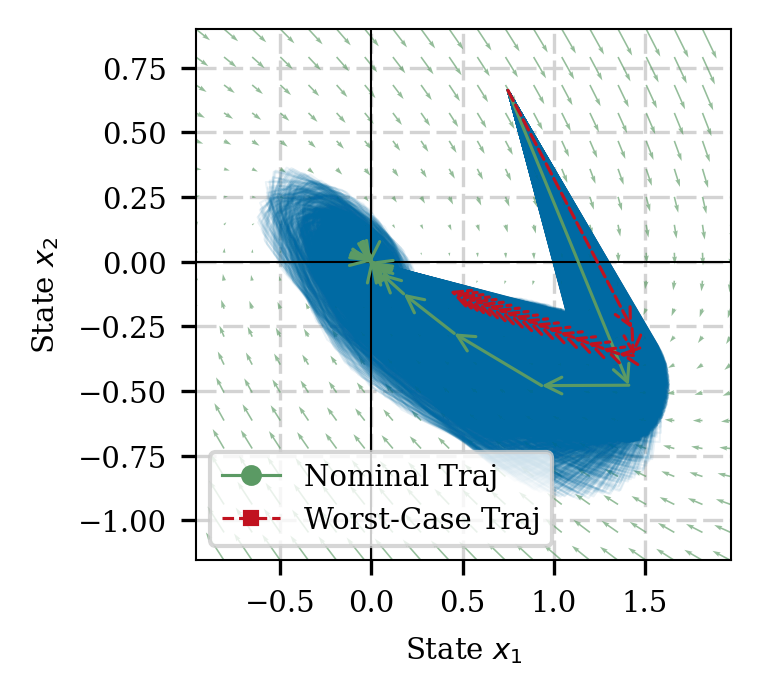

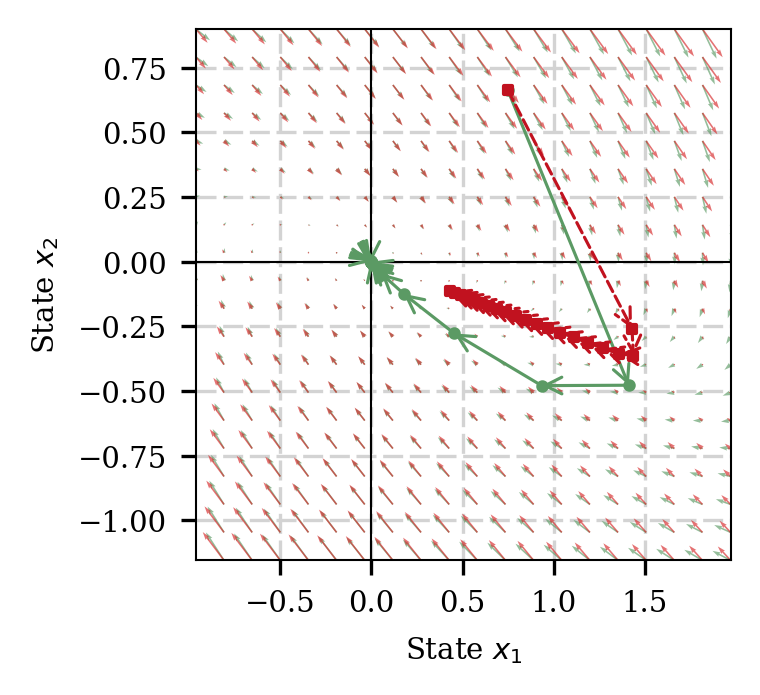

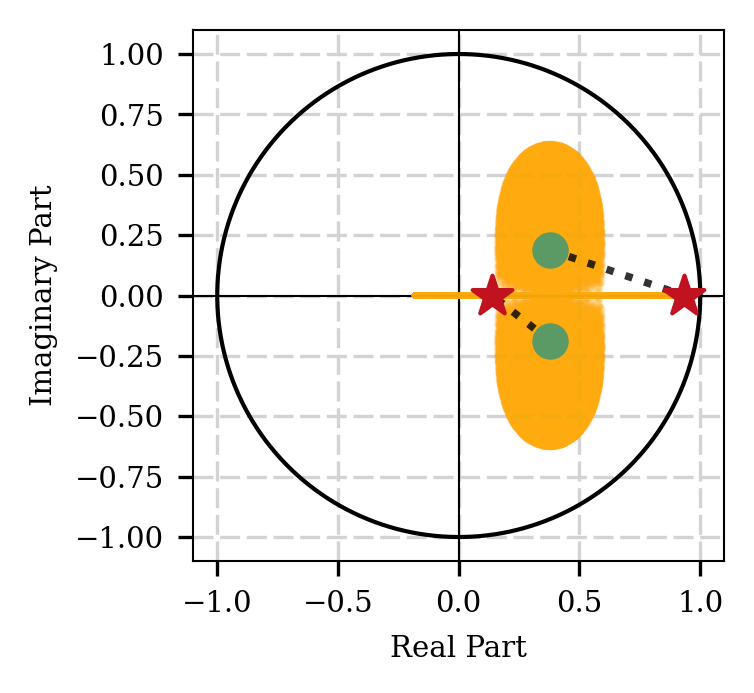

Success! Saved 4 files: 
- 'A_1_time_evolution.pdf'
- 'A_1_nominal_flow.pdf'
- 'A_1_worst_case_flow.pdf'
- 'A_1_spectral_targeting.pdf'


In [ ]:
params = {
    'A11': 1.0, 'A12': 1.0, 'A21': 0.0, 'A22': 1.0,
    'B1': 0.0, 'B2': 1.0,
    'Q11': 1.0, 'Q22': 1.0, 'R11': 1.0,
    'S11': 1.0, 'S22': 1.0,
    'eps_A': 0.22, 'eps_B': 0, 'N': 20,
    'apply_bm': True, 'num_sims': 5000
}

res, msg = solve_pep_2d(**params)

plot_function(res,'A_1')

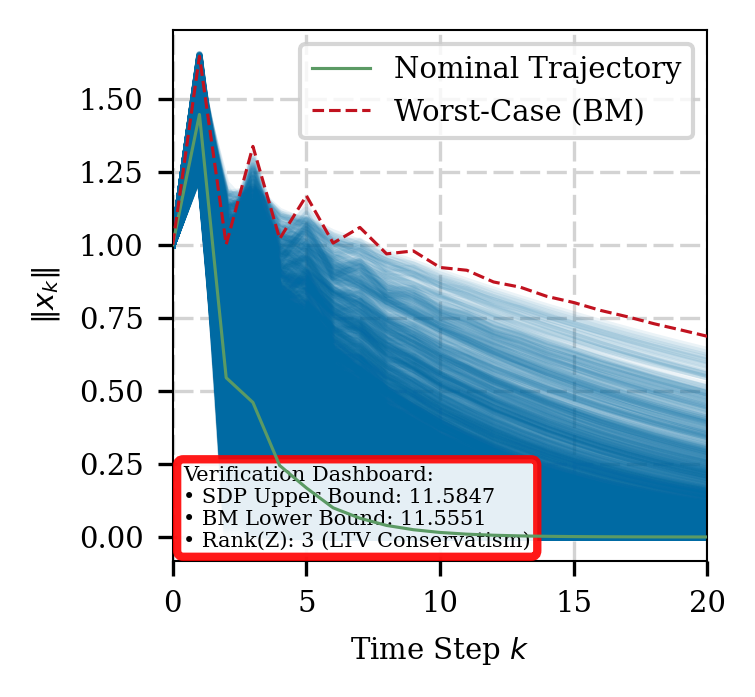

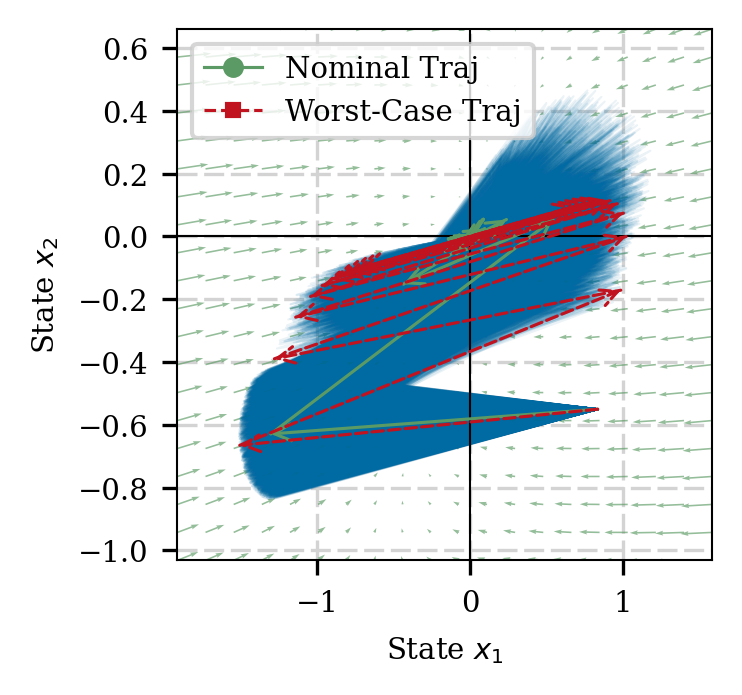

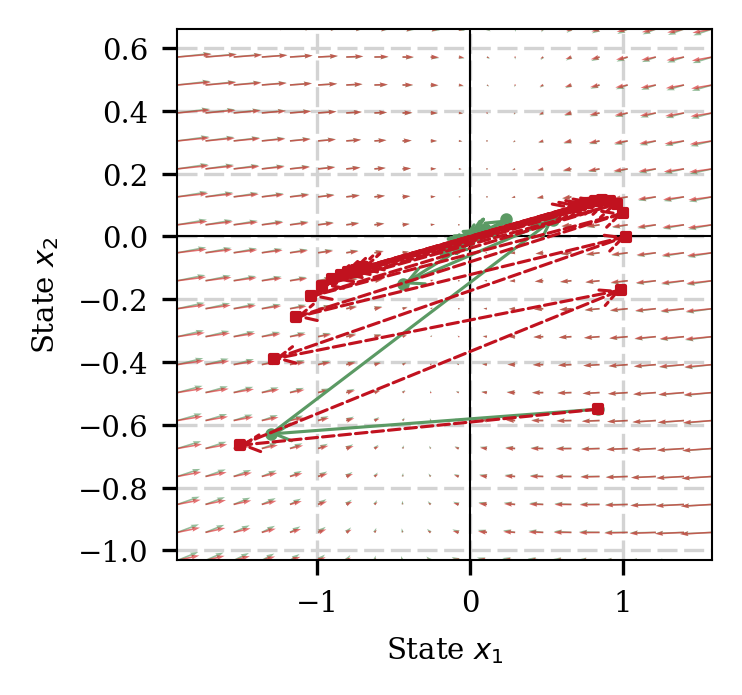

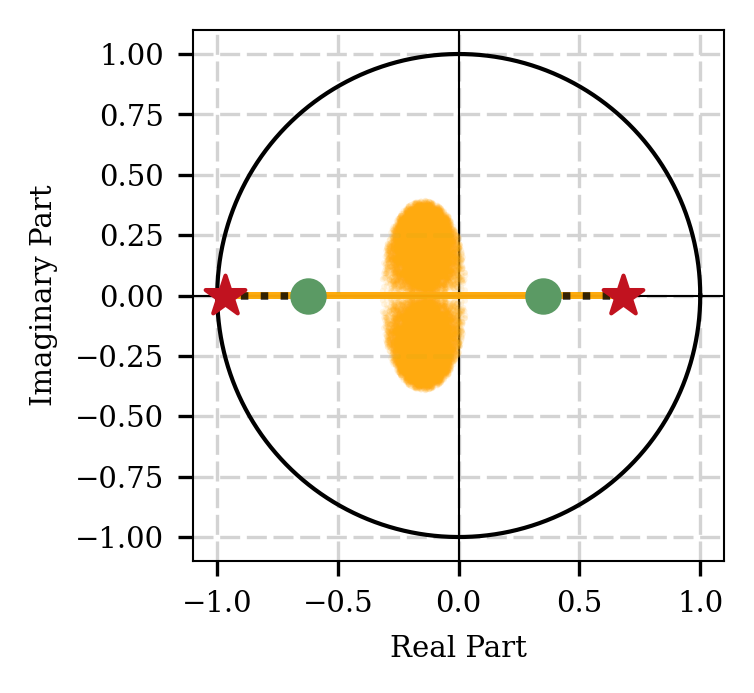

Success! Saved 4 files: 
- 'A_2_time_evolution.pdf'
- 'A_2_nominal_flow.pdf'
- 'A_2_worst_case_flow.pdf'
- 'A_2_spectral_targeting.pdf'


In [ ]:
params = {
    'A11': -.9, 'A12': 1, 'A21': 0.0, 'A22': 1.0,
    'B1': 0.0, 'B2': 1.0,
    'Q11': 1.0, 'Q22': 1.0, 'R11': 1.0,
    'S11': 1.0, 'S22': 1.0,
    'eps_A': 0.2, 'eps_B': 0.1, 'N': 20,
    'apply_bm': True, 'num_sims': 5000
}

res, msg = solve_pep_2d(**params)

plot_function(res,'A_2')

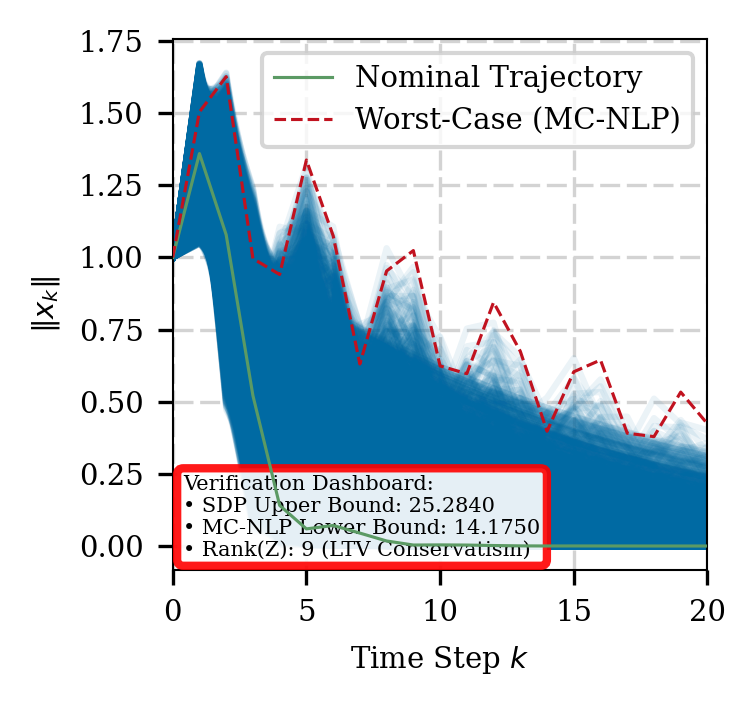

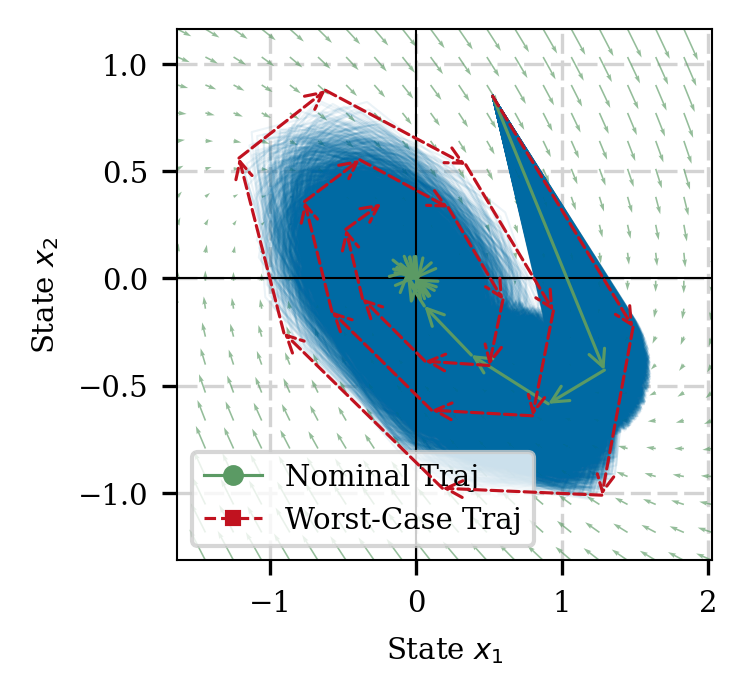

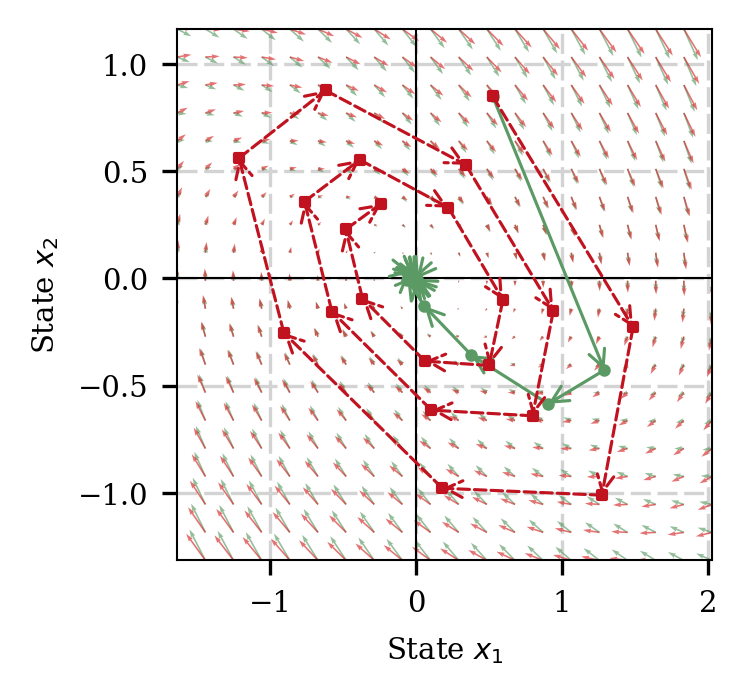

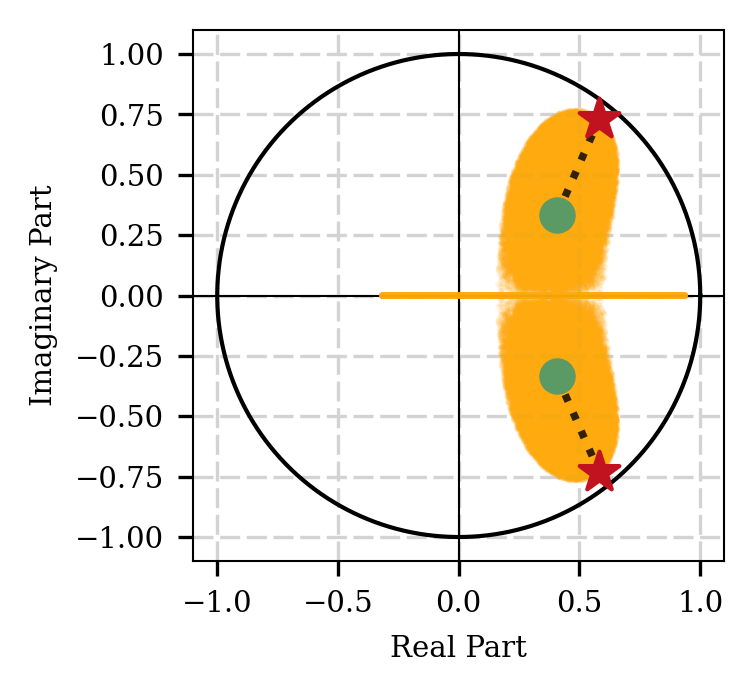

Success! Saved 4 files: 
- 'A_3_time_evolution.pdf'
- 'A_3_nominal_flow.pdf'
- 'A_3_worst_case_flow.pdf'
- 'A_3_spectral_targeting.pdf'


In [ ]:
params = {
    'A11': 1.0, 'A12': 0.9, 'A21': -.8, 'A22': 1.0,
    'B1': 0.0, 'B2': 1.0,
    'Q11': 1.0, 'Q22': 1.0, 'R11': 1.0,
    'S11': 1.0, 'S22': 1.0,
    'eps_A': 0.1, 'eps_B': 0.25, 'N': 20,
    'apply_bm': True, 'num_sims': 10000
}

res, msg = solve_pep_2d(**params)

plot_function(res,'A_3')

# Pole migration of the  worst case

In [ ]:

def match_poles(p_prev, p_curr):
    """Sorts poles to ensure continuous lines when drawing trajectory arrows."""
    d1 = abs(p_prev[0]-p_curr[0]) + abs(p_prev[1]-p_curr[1])
    d2 = abs(p_prev[0]-p_curr[1]) + abs(p_prev[1]-p_curr[0])
    return p_curr if d1 <= d2 else np.array([p_curr[1], p_curr[0]])

params = {
    'A11': 1.0, 'A12': 1.0, 'A21': 0.0, 'A22': 1.0,
    'B1': 0.0, 'B2': 1.0,
    'Q11': 1.0, 'Q22': 1.0, 'R11': 1.0,
    'S11': 0.0, 'S22': 1.0,  # Matches S = diag([0, 1])
    'eps_A': 0.15, 'eps_B': 0.05,
    'apply_bm': True, 'num_sims': 2000
}

# 1. Fetch Nominal matrices to generate the background Cloud
A, B, Q, R, _ = build_system_matrices(params['A11'], params['A12'], params['A21'], params['A22'],
                                      params['B1'], params['B2'], params['Q11'], params['Q22'],
                                      params['R11'], params['S11'], params['S22'])
_, K, Phi, _ = solve_nominal_lqr(A, B, Q, R)

print("Generating background perturbation cloud...")
cloud_eigs = generate_perturbation_cloud(Phi, K, params['eps_A'], params['eps_B'], N_samples=80000, n=2, m=1)

# 2. Run the Robust Pipeline over horizons N
N_values = list(range(2, 16))
wc_poles = {}

print("Running Robust Pipeline (SDP + BM + NLP) over Horizons N...")
for N in N_values:
    res, msg = solve_pep_2d(**params, N=N)
    if res is not None:
        wc_poles[N] = np.linalg.eigvals(res['Phi_wc'])
        print(f"  --> N={N:02d}: Bound mapped by {res['wc_method']}")
    else:
        print(f"  --> N={N:02d}: Failed ({msg})")



Generating background perturbation cloud...
Running Robust Pipeline (SDP + BM + NLP) over Horizons N...
  --> N=02: Bound mapped by BM
  --> N=03: Bound mapped by BM
  --> N=04: Bound mapped by MC-NLP
  --> N=05: Bound mapped by MC-NLP
  --> N=06: Bound mapped by MC-NLP
  --> N=07: Bound mapped by BM
  --> N=08: Bound mapped by BM
  --> N=09: Bound mapped by BM
  --> N=10: Bound mapped by MC-NLP
  --> N=11: Bound mapped by BM
  --> N=12: Bound mapped by BM
  --> N=13: Bound mapped by BM
  --> N=14: Bound mapped by BM
  --> N=15: Bound mapped by BM


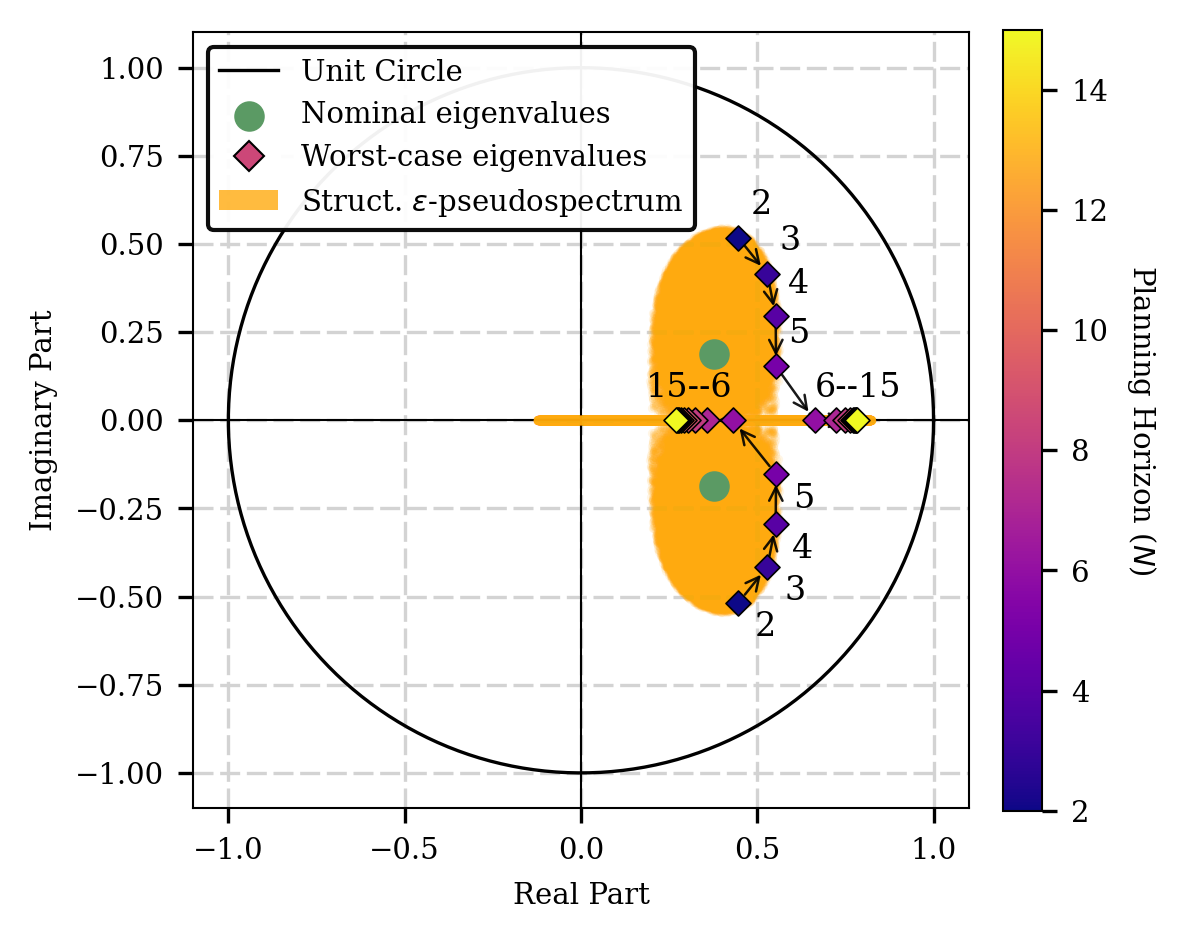


Success! Plot saved as spectral_migration_trajectory_2D.pdf.


In [ ]:
# ==========================================
# Plotting the Trajectory Visualization
# ==========================================
fig, ax = plt.subplots(figsize=(4,4), dpi=300)

ax.grid(True)
# Background shapes (Axes, Unit Circle, Cloud)
ax.axhline(0, color='black', lw=0.5, zorder=1)
ax.axvline(0, color='black', lw=0.5, zorder=1)

theta = np.linspace(0, 2*np.pi, 200)
ax.plot(np.cos(theta), np.sin(theta), 'k-', lw=0.8, label='Unit Circle', zorder=1)
ax.scatter(cloud_eigs.real, cloud_eigs.imag, c="#ffaa0f", s=1.5, alpha=0.1, zorder=2, rasterized=True)

# Nominal Poles (Static)
eigs_nom = np.linalg.eigvals(Phi)
ax.scatter(eigs_nom.real, eigs_nom.imag, s=40, c=C_NOM, marker='o',  zorder=5, label='Nominal eigenvalues')

# Dynamic Plotting of Worst-Case Poles with Colormap and Arrows
cmap = mpl.cm.plasma
norm = mpl.colors.Normalize(vmin=min(N_values), vmax=max(N_values))

prev_poles = None
list_length = len(N_values)  # Store the list length

# Wrapped N_values with enumerate to track the index
for idx, N in enumerate(N_values):
    if N not in wc_poles: continue
    p = wc_poles[N]

    if prev_poles is not None:
        p = match_poles(prev_poles, p)
        for i in range(len(p)):
            ax.annotate('', xy=(p[i].real, p[i].imag), xytext=(prev_poles[i].real, prev_poles[i].imag),
                        arrowprops=dict(arrowstyle='->', color='black', lw=0.6, alpha=0.9, shrinkA=2.5, shrinkB=2.5), zorder=4)

    color = cmap(norm(N))
    ax.scatter(p.real, p.imag, s=18, color=color, marker='D', edgecolors='black', linewidths=0.4, zorder=6)

    # ----------------------------------------------------
    # NEW: Add label to the top right of the scatter point
    # ----------------------------------------------------
    # Check if this is the 8-to-last point
    if N_values[idx] > 5:
        if N_values[idx] == 6:


            for i in range(len(p)):
                if i ==0:
                    label_text = f"6--{list_length+1}"
                    ax.annotate(label_text,
                                xy=(p[i].real, p[i].imag),
                                xytext=(0, 4),           # (x, y) offset in points (top-right direction)
                                textcoords='offset points',
                                ha='left',               # Horizontal alignment
                                va='bottom',             # Vertical alignment
                                fontsize=8,              # Slightly smaller font to prevent clutter
                                color='black',           # Set to 'color' if you want it to match the marker
                                zorder=10)
                if i ==1:
                    label_text = f"{list_length+1}--6"
                    ax.annotate(label_text,
                                xy=(p[i].real, p[i].imag),
                                xytext=(-0, 4),           # (x, y) offset in points (top-right direction)
                                textcoords='offset points',
                                ha='right',               # Horizontal alignment
                                va='bottom',             # Vertical alignment
                                fontsize=8,              # Slightly smaller font to prevent clutter
                                color='black',           # Set to 'color' if you want it to match the marker
                                zorder=10)
        else :
            label_text =''
    else:
        label_text = str(N)

        for i in range(len(p)):
            if i ==0:
                ax.annotate(label_text,
                            xy=(p[i].real, p[i].imag),
                            xytext=(3, 4),           # (x, y) offset in points (top-right direction)
                            textcoords='offset points',
                            ha='left',               # Horizontal alignment
                            va='bottom',             # Vertical alignment
                            fontsize=8,              # Slightly smaller font to prevent clutter
                            color='black',           # Set to 'color' if you want it to match the marker
                            zorder=10)
            if i ==1:
                ax.annotate(label_text,
                            xy=(p[i].real, p[i].imag),
                            xytext=(4, -2),           # (x, y) offset in points (top-right direction)
                            textcoords='offset points',
                            ha='left',               # Horizontal alignment
                            va='top',             # Vertical alignment
                            fontsize=8,              # Slightly smaller font to prevent clutter
                            color='black',           # Set to 'color' if you want it to match the marker
                            zorder=10)
    # ----------------------------------------------------

    prev_poles = p

# Colorbar to show the N mapping
sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])
cbar = fig.colorbar(sm, ax=ax, fraction=0.046, pad=0.04)
cbar.set_label('Planning Horizon ($N$)', rotation=270, labelpad=12, fontsize=7)
cbar.ax.tick_params(labelsize=7)

# Formatting
ax.set_xlim(-1.1, 1.1)
ax.set_ylim(-1.1, 1.1)
ax.set_aspect('equal')
ax.set_xlabel("Real Part")
ax.set_ylabel("Imaginary Part")

# Custom Legend
handles, labels = ax.get_legend_handles_labels()
cloud_patch = mpatches.Patch(facecolor="#ffaa0f", alpha=0.8, label=r'Struct. $\varepsilon$-pseudospectrum')
wc_marker = mpl.lines.Line2D([0], [0], marker='D', color='w', markerfacecolor=cmap(0.5), markeredgecolor='k', markersize=5, markeredgewidth=0.5, label='Worst-case eigenvalues')

handles.extend([wc_marker, cloud_patch])
labels.extend([wc_marker.get_label(), cloud_patch.get_label()])
ax.legend(handles=handles, labels=labels, loc='upper left', framealpha=0.95, edgecolor='black')

plt.tight_layout()
filename = "spectral_migration_trajectory_2D.pdf"
fig.savefig(filename, bbox_inches='tight', format="pdf")
plt.show()

print(f"\nSuccess! Plot saved as {filename}.")

## Comparaison with other approaches

In [ ]:
import time

n, m = 2, 1
A = np.array([[1.0, 1.0], [0.0, 1.0]])
B = np.array([[0.0], [1.0]])
Q = np.eye(n)
R = np.eye(m)
S = np.eye(n)

eps_A, eps_B = 0.15, 0.05

# Nominal LQR Controller
P_lqr = solve_discrete_are(A, B, Q, R)
K = np.linalg.inv(R + B.T @ P_lqr @ B) @ (B.T @ P_lqr @ A)
Phi = A - B @ K
Q_K = Q + K.T @ R @ K


# ==========================================
# 2. Heuristics & Lower Bound Extractors
# ==========================================
def random_delta(rows, cols):
    M = np.random.randn(rows, cols)
    u, s, vh = np.linalg.svd(M, full_matrices=False)
    s_rand = np.random.uniform(0, 1, size=len(s))
    if len(s_rand) > 0: s_rand[0] = 1.0
    return (u * s_rand) @ vh

def get_monte_carlo_lower_bound(Phi, K, Q_K, S, eps_A, eps_B, N, num_sims=5000):
    max_cost = 0.0
    best_DA, best_DB, best_x0 = None, None, None
    for _ in range(num_sims):
        Delta_A = eps_A * random_delta(n, n)
        Delta_B = eps_B * random_delta(n, m)
        Phi_D = Phi + Delta_A - Delta_B @ K
        P_curr = S
        for _ in range(N):
            P_curr = Q_K + Phi_D.T @ P_curr @ Phi_D
        w, v = np.linalg.eigh(P_curr)
        cost = w[-1]
        if cost > max_cost:
            max_cost = cost
            best_DA, best_DB, best_x0 = Delta_A, Delta_B, v[:, -1]
    return max_cost, best_DA, best_DB, best_x0

def run_pseudospectral_heuristic(Phi, K, Q_K, S_active, eps_A, eps_B, N, n=2, m=1, num_samples=6000):
    """
    Finds the LTI perturbation that maximizes the spectral radius (asymptotic worst-case),
    and computes its exact finite-horizon cost to demonstrate the difference between
    transient and asymptotic bounds.
    """
    # 1. Batch generate random perturbations that saturate the norm bound
    if eps_A > 0:
        M_A = np.random.randn(num_samples, n, n)
        U_A, S_A, Vh_A = np.linalg.svd(M_A)
        Sr_A = np.random.uniform(0, 1, size=S_A.shape)
        Sr_A[:, 0] = 1.0 # Force max singular value to 1 to sit on the boundary
        DA_batch = eps_A * ((U_A * Sr_A[:, np.newaxis, :]) @ Vh_A)
    else:
        DA_batch = np.zeros((num_samples, n, n))

    if eps_B > 0:
        M_B = np.random.randn(num_samples, n, m)
        U_B, S_B, Vh_B = np.linalg.svd(M_B, full_matrices=False)
        Sr_B = np.random.uniform(0, 1, size=S_B.shape)
        Sr_B[:, 0] = 1.0
        DB_batch = eps_B * ((U_B * Sr_B[:, np.newaxis, :]) @ Vh_B)
    else:
        DB_batch = np.zeros((num_samples, n, m))

    # 2. Compute the closed-loop matrices and find the max spectral radius
    K_batch = np.broadcast_to(K, (num_samples, m, n))
    Phi_batch = Phi + DA_batch - DB_batch @ K_batch

    eigs_batch = np.linalg.eigvals(Phi_batch)
    radii = np.max(np.abs(eigs_batch), axis=1)
    best_idx = np.argmax(radii)

    Phi_wc_ps = Phi_batch[best_idx]

    # 3. Find the worst-case initial state for this specific asymptotic perturbation
    P_curr = S_active
    for _ in range(N):
        P_curr = Q_K + Phi_wc_ps.T @ P_curr @ Phi_wc_ps
    w, v = np.linalg.eigh(P_curr)
    x0_ps = v[:, -1]

    # 4. Rollout to compute exact finite-horizon cost
    true_valid_cost = 0.0
    x = x0_ps
    traj_s, traj_n = [x0_ps], [np.linalg.norm(x0_ps)]
    for _ in range(N):
        true_valid_cost += (x.T @ Q_K @ x)
        x = Phi_wc_ps @ x
        traj_s.append(x); traj_n.append(np.linalg.norm(x))
    true_valid_cost += (x.T @ S_active @ x)

    return {
        'cost': true_valid_cost, 'Phi_wc': Phi_wc_ps,
        'traj_s': traj_s, 'traj_n': traj_n, 'x0': x0_ps,
        'max_radius': radii[best_idx]
    }

def run_nlp_heuristic(x0_guess, DA_guess, DB_guess, Phi, K, Q_K, S, eps_A, eps_B, N):
    def pack(x0, DA, DB): return np.concatenate([x0, DA.flatten(), DB.flatten()])
    def unpack(theta): return theta[:n], theta[n : n + n*n].reshape((n, n)), theta[n + n*n :].reshape((n, m))

    def cost_fn(theta):
        x0, DA, DB = unpack(theta)
        Phi_wc = Phi + DA - DB @ K
        x, J = x0, 0.0
        for _ in range(N):
            J += x.T @ Q_K @ x
            x = Phi_wc @ x
        return -(J + x.T @ S @ x)

    cons = [
        {'type': 'ineq', 'fun': lambda theta: 1.0 - np.sum(unpack(theta)[0]**2)},
        {'type': 'ineq', 'fun': lambda theta: eps_A - np.linalg.norm(unpack(theta)[1], ord=2)},
        {'type': 'ineq', 'fun': lambda theta: eps_B - np.linalg.norm(unpack(theta)[2], ord=2)}
    ]
    bnds = [(-1.0, 1.0)] * n + [(-eps_A, eps_A)] * (n*n) + [(-eps_B, eps_B)] * (n*m)

    res = minimize(cost_fn, pack(x0_guess, DA_guess, DB_guess), method='SLSQP', bounds=bnds, constraints=cons,
                   options={'maxiter': 200, 'ftol': 1e-6, 'disp': False})

    x0_f, DA_f, DB_f = unpack(res.x)
    if np.linalg.norm(x0_f) > 1e-8: x0_f = x0_f / max(1.0, np.linalg.norm(x0_f))

    if eps_A > 0:
        u, s, vh = np.linalg.svd(DA_f, full_matrices=False)
        DA_f = u @ np.diag(np.minimum(s, eps_A)) @ vh
    if eps_B > 0:
        u, s, vh = np.linalg.svd(DB_f, full_matrices=False)
        DB_f = u @ np.diag(np.minimum(s, eps_B)) @ vh

    Phi_wc = Phi + DA_f - DB_f @ K
    x, true_valid_cost = x0_f, 0.0
    for _ in range(N):
        true_valid_cost += x.T @ Q_K @ x
        x = Phi_wc @ x
    return true_valid_cost + x.T @ S @ x

def extract_warm_start(Z_val, Phi, K, N, eps_A, eps_B):
    w, v = np.linalg.eigh(Z_val)
    y = v[:, -1] * np.sqrt(max(w[-1], 0.0))
    x0 = y[:n]
    if np.linalg.norm(x0) > 1.0: x0 = x0 / np.linalg.norm(x0)

    X, V_A, V_B = np.zeros((n, N)), np.zeros((n, N)), np.zeros((n, N))
    x_curr = x0
    for k in range(N):
        X[:, k] = x_curr
        vA = y[n + k*n : n + (k+1)*n]
        vB = y[n + N*n + k*n : n + N*n + (k+1)*n]
        V_A[:, k], V_B[:, k] = vA, vB
        x_curr = Phi @ x_curr + vA - vB

    Delta_A = V_A @ np.linalg.pinv(X)
    Delta_B = V_B @ np.linalg.pinv(K @ X)

    u, s, vh = np.linalg.svd(Delta_A, full_matrices=False)
    Delta_A = u @ np.diag(np.minimum(s, eps_A)) @ vh
    u, s, vh = np.linalg.svd(Delta_B, full_matrices=False)
    Delta_B = u @ np.diag(np.minimum(s, eps_B)) @ vh
    return x0, Delta_A, Delta_B

def solve_burer_monteiro(Z_sdp, M_obj, H_x, H_vA, H_vB, K, N, n):
    n_tot = Z_sdp.shape[0]
    M_obj = (M_obj + M_obj.T) / 2.0

    eigs, evecs = np.linalg.eigh(Z_sdp)
    best_obj_val, y0 = -np.inf, None
    for i in range(len(eigs)):
        if eigs[i] > 1e-8:
            y_candidate = evecs[:, i] * np.sqrt(eigs[i])
            # Uses 1.0 multiplier here matching 6D cost matrix scale
            candidate_obj_val = y_candidate.T @ M_obj @ y_candidate
            if candidate_obj_val > best_obj_val:
                best_obj_val, y0 = candidate_obj_val, y_candidate.copy()

    if y0 is None: y0 = np.zeros(n_tot)

    # FIXED: Scale adjusted to 1.0 to perfectly match 6D system cost matrices
    def obj(y): return -1.0 * y.T @ M_obj @ y
    def obj_jac(y): return -2.0 * M_obj @ y
    def cons_init(y): return 1.0 - np.dot(y[0:n], y[0:n])
    def cons_init_jac(y):
        jac = np.zeros_like(y); jac[0:n] = -2.0 * y[0:n]; return jac

    def get_matrices(y):
        X = np.column_stack([H_x[k] @ y for k in range(N)])
        VA = np.column_stack([H_vA[k] @ y for k in range(N)])
        VB = np.column_stack([H_vB[k] @ y for k in range(N)])
        return X.T @ X, VA.T @ VA, VB.T @ VB, (K @ X).T @ (K @ X)

    def cons_lmi_A(y):
        Gx, Gva, _, _ = get_matrices(y)
        return np.linalg.eigvalsh(eps_A**2 * Gx - Gva + 1e-7 * np.eye(N))

    def cons_lmi_B(y):
        _, _, Gvb, Gkx = get_matrices(y)
        return np.linalg.eigvalsh(eps_B**2 * Gkx - Gvb + 1e-7 * np.eye(N))

    constraints = [
        {'type': 'ineq', 'fun': cons_init, 'jac': cons_init_jac},
        {'type': 'ineq', 'fun': cons_lmi_A},
        {'type': 'ineq', 'fun': cons_lmi_B}
    ]

    res = minimize(obj, y0, method='SLSQP', jac=obj_jac, constraints=constraints,
                   options={'maxiter': 500, 'ftol': 1e-8, 'disp': False})

    return -res.fun, np.outer(res.x, res.x)

# ==========================================
# 3. Main Fast Solver Pipeline
# ==========================================
def build_extraction_matrices(Phi, N, n):
    n_tot = n * (1 + 2 * N)
    H_x, H_vA, H_vB = [np.zeros((n, n_tot)) for _ in range(N + 1)], [np.zeros((n, n_tot)) for _ in range(N)], [np.zeros((n, n_tot)) for _ in range(N)]
    H_x[0][:, :n] = np.eye(n)
    for k in range(N):
        H_vA[k][:, n + k*n : n + (k+1)*n] = np.eye(n)
        H_vB[k][:, n + n*N + k*n : n + n*N + (k+1)*n] = np.eye(n)
        H_x[k+1] = Phi @ H_x[k] + H_vA[k] - H_vB[k]
    return H_x, H_vA, H_vB, n_tot

def solve_pipeline(Phi, K, Q_K, S, eps_A, eps_B, N, mc_params):
    H_x, H_vA, H_vB, n_tot = build_extraction_matrices(Phi, N, n)
    M_J = sum([H_x[k].T @ Q_K @ H_x[k] for k in range(N)]) + H_x[N].T @ S @ H_x[N]

    def fast_inner(C_mat, Z_vec):
        return C_mat.flatten(order='F') @ Z_vec

    # --- 1. IQC (LTV Bound) ---
    Z_iqc = cp.Variable((n_tot, n_tot), symmetric=True)
    z_iqc_vec = cp.vec(Z_iqc)

    cons_iqc = [Z_iqc >> 0, fast_inner(H_x[0].T @ H_x[0], z_iqc_vec) <= 1]
    for k in range(N):
        cons_iqc.append(fast_inner(eps_A**2 * (H_x[k].T @ H_x[k]) - (H_vA[k].T @ H_vA[k]), z_iqc_vec) >= 0)
        cons_iqc.append(fast_inner(eps_B**2 * (H_x[k].T @ K.T @ K @ H_x[k]) - (H_vB[k].T @ H_vB[k]), z_iqc_vec) >= 0)

    prob_iqc = cp.Problem(cp.Maximize(fast_inner(M_J, z_iqc_vec)), cons_iqc)
    prob_iqc.solve()
    cost_iqc = prob_iqc.value

    # --- 2. PEP Relaxed (LTV Bound) ---
    t0_sdp = time.time()
    Z_pep = cp.Variable((n_tot, n_tot), symmetric=True)
    z_pep_vec = cp.vec(Z_pep)
    cons_pep = [Z_pep >> 0, fast_inner(H_x[0].T @ H_x[0], z_pep_vec) <= 1]

    G_x, G_vA, G_Kx, G_vB = [cp.Variable((N, N), symmetric=True) for _ in range(4)]
    for i in range(N):
        for j in range(i, N):
            cons_pep.append(G_x[i,j] == fast_inner(H_x[j].T @ H_x[i], z_pep_vec))
            cons_pep.append(G_vA[i,j] == fast_inner(H_vA[j].T @ H_vA[i], z_pep_vec))
            cons_pep.append(G_Kx[i,j] == fast_inner(H_x[j].T @ K.T @ K @ H_x[i], z_pep_vec))
            cons_pep.append(G_vB[i,j] == fast_inner(H_vB[j].T @ H_vB[i], z_pep_vec))

    cons_pep.append(eps_A**2 * G_x - G_vA >> 0)
    cons_pep.append(eps_B**2 * G_Kx - G_vB >> 0)

    prob_pep = cp.Problem(cp.Maximize(fast_inner(M_J, z_pep_vec)), cons_pep)
    prob_pep.solve()
    t1_sdp = time.time()

    cost_pep_relaxed = prob_pep.value
    Z_val = Z_pep.value
    rank_Z = np.sum(np.clip(np.linalg.eigvalsh(Z_val), 0, None) > 1e-4 * np.max(np.linalg.eigvalsh(Z_val)))

    # --- 3. Exact LTI Lower Bounds Pipeline ---
    t0_heur = time.time()
    x0_mc, DA_mc, DB_mc, cost_mc = mc_params

    # Heuristic A: MC-Seeded NLP
    cost_nlp_mc = run_nlp_heuristic(x0_mc, DA_mc, DB_mc, Phi, K, Q_K, S, eps_A, eps_B, N)

    # Heuristic B: Pseudospectral Edge Targeting
    ps_res = run_pseudospectral_heuristic(Phi, K, Q_K, S, eps_A, eps_B, N, n=n, m=m, num_samples=6000)
    # The PS heuristic formulation utilizes a 0.5 scalar for cost, we multiply by 2
    cost_ps = ps_res['cost']

    # Heuristic C: Burer-Monteiro QCQP & SDP-Seeded NLP
    if rank_Z > 1:
        c_bm, Z_bm = solve_burer_monteiro(Z_val, M_J, H_x, H_vA, H_vB, K, N, n)
        if c_bm > cost_pep_relaxed:
            c_bm = 0
        x0_sdp, DA_sdp, DB_sdp = extract_warm_start(Z_bm, Phi, K, N, eps_A, eps_B)
        cost_nlp_sdp = run_nlp_heuristic(x0_sdp, DA_sdp, DB_sdp, Phi, K, Q_K, S, eps_A, eps_B, N)
        print(f'BM: {c_bm:.2f} |  MC + NLP: {cost_nlp_sdp:.2f}')
    else:
        cost_nlp_sdp = cost_pep_relaxed

    exact_lti_cost = max(cost_nlp_mc, cost_ps, cost_nlp_sdp, cost_mc)
    t1_heur = time.time()

    return cost_iqc, cost_pep_relaxed, exact_lti_cost, cost_ps, rank_Z, (t1_sdp - t0_sdp), (t1_heur - t0_heur)

# ==========================================
# 4. Execution Loop
# ==========================================
horizons = list(range(2, 21))

iqc_costs = []
pep_relax_costs = []
exact_costs = []
ps_costs = []
mc_costs = []

for N in horizons:
    t0_mc = time.time()
    c_mc, DA_mc, DB_mc, x0_mc = get_monte_carlo_lower_bound(Phi, K, Q_K, S, eps_A, eps_B, N, num_sims=8000)
    t1_mc = time.time()

    c_iqc, c_pep_relax, c_exact, c_ps, r_relax, t_sdp, t_heur = solve_pipeline(
        Phi, K, Q_K, S, eps_A, eps_B, N, (x0_mc, DA_mc, DB_mc, c_mc)
    )

    iqc_costs.append(c_iqc)
    pep_relax_costs.append(c_pep_relax)
    exact_costs.append(c_exact)
    ps_costs.append(c_ps)
    mc_costs.append(c_mc)

    print(f"N={N:2d} | Rank(Z): {r_relax} | SDP Time: {t_sdp:.3f}s | Heuristics Time: {t_heur:.3f}s")
    print(f"      Upper Bounds -> IQC (LTV): {c_iqc:.2f} | PEP (Relaxed): {c_pep_relax:.2f}")
    print(f"      Lower Bounds -> Exact Max: {c_exact:.2f} | Pseudo: {c_ps:.2f} | MC: {c_mc:.2f}\n")




/usr/local/lib/python3.13/dist-packages/cvxpy/atoms/affine/vec.py:40: FutureWarning: 
    You didn't specify the order of the vec expression. The default order
    used in CVXPY is Fortran ('F') order. This default will change to match NumPy's
    default order ('C') in a future version of CVXPY.
    To suppress this warning, please specify the order explicitly.
    
  warnings.warn(vec_order_warning, FutureWarning)


N= 2 | Rank(Z): 1 | SDP Time: 3.544s | Heuristics Time: 0.175s
      Upper Bounds -> IQC (LTV): 7.91 | PEP (Relaxed): 7.87
      Lower Bounds -> Exact Max: 7.87 | Pseudo: 6.78 | MC: 7.84

BM: 0.00 |  MC + NLP: 9.26
N= 3 | Rank(Z): 2 | SDP Time: 2.084s | Heuristics Time: 0.922s
      Upper Bounds -> IQC (LTV): 9.50 | PEP (Relaxed): 9.26
      Lower Bounds -> Exact Max: 9.26 | Pseudo: 8.34 | MC: 9.20

BM: 9.99 |  MC + NLP: 9.99
N= 4 | Rank(Z): 2 | SDP Time: 2.767s | Heuristics Time: 7.813s
      Upper Bounds -> IQC (LTV): 10.50 | PEP (Relaxed): 10.00
      Lower Bounds -> Exact Max: 9.99 | Pseudo: 8.94 | MC: 9.84



/usr/local/lib/python3.13/dist-packages/cvxpy/problems/problem.py:1510: UserWarning: Solution may be inaccurate. Try another solver, adjusting the solver settings, or solve with verbose=True for more information.
  warnings.warn(


BM: 10.41 |  MC + NLP: 10.40
N= 5 | Rank(Z): 2 | SDP Time: 17.386s | Heuristics Time: 8.929s
      Upper Bounds -> IQC (LTV): 11.15 | PEP (Relaxed): 10.51
      Lower Bounds -> Exact Max: 10.40 | Pseudo: 9.74 | MC: 10.35

BM: 10.67 |  MC + NLP: 10.67
N= 6 | Rank(Z): 2 | SDP Time: 12.858s | Heuristics Time: 5.718s
      Upper Bounds -> IQC (LTV): 11.57 | PEP (Relaxed): 10.89
      Lower Bounds -> Exact Max: 10.67 | Pseudo: 10.15 | MC: 10.57

BM: 10.84 |  MC + NLP: 10.61
N= 7 | Rank(Z): 3 | SDP Time: 8.661s | Heuristics Time: 5.974s
      Upper Bounds -> IQC (LTV): 11.86 | PEP (Relaxed): 11.13
      Lower Bounds -> Exact Max: 10.84 | Pseudo: 10.23 | MC: 10.74

BM: 10.95 |  MC + NLP: 10.95
N= 8 | Rank(Z): 3 | SDP Time: 25.066s | Heuristics Time: 12.584s
      Upper Bounds -> IQC (LTV): 12.05 | PEP (Relaxed): 11.28
      Lower Bounds -> Exact Max: 10.95 | Pseudo: 9.75 | MC: 10.82

BM: 11.02 |  MC + NLP: 11.02
N= 9 | Rank(Z): 3 | SDP Time: 28.077s | Heuristics Time: 15.151s
      Upper Boun

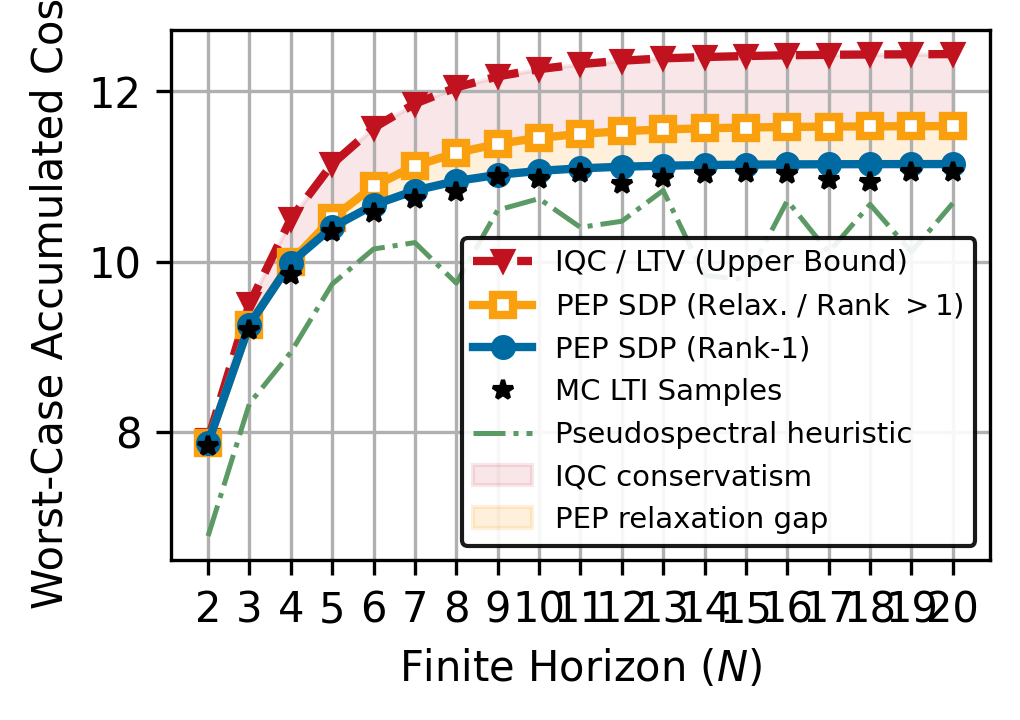

Success! Plot saved as cost_comparaison.pdf.


In [ ]:

myblue = '#006AA3'
myorange = "#FAA00F"
myred = "#C1121F"
mygreen = "#5B9A64"

# ==========================================
# Plotting the Conservativeness Gap
# ==========================================
plt.figure(figsize=(3.5, 2.5),dpi=300)

# 1. IQC / LTV
plt.plot(horizons, iqc_costs, '--v', color=myred, lw=2.0, markersize=5, label='IQC / LTV (Upper Bound)')

# 2. Relaxed PEP
plt.plot(horizons, pep_relax_costs, '-s', color=myorange, lw=2.0, markersize=5, markerfacecolor='white', markeredgewidth=2, label=r'PEP SDP (Relax. / Rank $> 1$)')

# 3. Exact PEP (Rank 1)
plt.plot(horizons, exact_costs, '-o', color=myblue, lw=2.0, markersize=5, label='PEP SDP (Rank-1)')

# 4. Monte Carlo
plt.plot(horizons, mc_costs, '*k', markersize=5, zorder=10, label='MC LTI Samples')
plt.plot(horizons, ps_costs, color=mygreen, linestyle='-.', linewidth=1.2, label='Pseudospectral heuristic')


# Fill standard IQC conservatism (Red)
plt.fill_between(horizons, pep_relax_costs, iqc_costs, color=myred, alpha=0.1, label='IQC conservatism')

# Fill the Relaxation Gap (Orange)
plt.fill_between(horizons, exact_costs, pep_relax_costs, color=myorange, alpha=0.15, label='PEP relaxation gap')

# Formatting
plt.xlabel("Finite Horizon ($N$)")
plt.ylabel("Worst-Case Accumulated Cost")
plt.xticks(horizons)
plt.grid(True)

# Legend Configuration
plt.legend(loc='lower right', framealpha=0.9, edgecolor='black', fontsize=7)

plt.tight_layout()
filename = "cost_comparaison.pdf"
plt.savefig(filename, transparent=True, bbox_inches='tight', format="pdf")
plt.show()

print(f"Success! Plot saved as {filename}.")